# Projeto Final IA - 1o sem 2026
*   Aline Nataly Lima de Moura - 164905
*   Tema: Análise de Sentimentos de Avaliações no E-commerce






# 0- Imports e funções

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re
from sklearn.model_selection import train_test_split
%matplotlib inline
pd.set_option('display.max_columns', 50)
import warnings
warnings.filterwarnings('ignore')
import time
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score, StratifiedKFold

import time, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import os
import warnings

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silencia mensagens informativas e alertas do TensorFlow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [61]:
# Dicionário com as suas configurações personalizadas
config_global = {
    "axes.facecolor": "#F4F4F6",      # Fundo do gráfico cinza bem claro (gelo)
    "figure.facecolor": "#FFFFFF",    # Fundo externo ao gráfico branco
    "axes.grid": True,                # Liga a grade
    "axes.grid.axis": "y",            # Grade apenas nas horizontais (eixo Y)
    "grid.color": "#FFFFFF",          # Cor da grade branca
    "grid.linewidth": 1.5,            # Espessura da grade
    "axes.edgecolor": "#FAF8F8",      # A MÁGICA AQUI: Contorno cinza em toda a volta
    "axes.linewidth": 1.2,            # Espessura do contorno cinza
    "axes.spines.top": False,          # Mantém contorno superior
    "axes.spines.right": True,        # Mantém contorno direito
    "text.color": "#333333",          # Cor neutra para os títulos
    "axes.labelcolor": "#555555",     # Cor neutra para o nome dos eixos
    "xtick.color": "#555555",         # Cor dos valores no eixo X
    "ytick.color": "#555555",         # Cor dos valores no eixo Y
}

# Aplica as configurações globais
sns.set_theme(style="ticks", rc=config_global)
estilo_caixa = dict(boxstyle="round,pad=0.1", facecolor="#CAC9C9",
                        edgecolor="#CAC9C9", alpha=0.3)
paleta_padrao = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860']

In [62]:

def criar_grafico(df, col_x=None, cols_y=None, labels_y=None, tipo='linha',
                  titulo='Título do Gráfico', xlabel=None, ylabel=None,
                  paleta=None, orientacao='v', margem_y=0.5, ylim=None, xlim=None,
                  figsize=(10, 5), ax=None, loc_pizza=None, bins=10):

    criar_figura_propria = ax is None
    if criar_figura_propria:
        fig, ax = plt.subplots(figsize=figsize)

    if paleta is None:
        paleta = 'colorblind'

    if labels_y is None and cols_y is not None:
        labels_y = cols_y

    # Caixinha cinza original com transparência (alpha=0.3)
    estilo_caixa = dict(boxstyle="round,pad=0.1", facecolor="#CAC9C9",
                        edgecolor="#CAC9C9", alpha=0.3)

    multiplos_dfs = isinstance(df, list)

    # 1. LINHA
    if tipo == 'linha':
        for i, col_y in enumerate(cols_y):
            cor = paleta[i % len(paleta)]
            df_atual = df[i] if multiplos_dfs else df
            ax.plot(df_atual[col_x], df_atual[col_y], marker="o", markersize=6,
                    linewidth=2.5, color=cor, label=labels_y[i])

            for x, y in zip(df_atual[col_x], df_atual[col_y]):
                offset = margem_y if i % 2 == 0 else -margem_y
                alinhamento = 'bottom' if i % 2 == 0 else 'top'
                ax.text(x, y + offset, f'{y:.1f}', color="#333333", ha='center',
                        va=alinhamento, fontsize=9, fontweight='bold', bbox=estilo_caixa)

    # 2. BARRA
    elif tipo == 'barra':
        if multiplos_dfs:
            raise ValueError("O tipo 'barra' atualmente só aceita um único DataFrame. Por favor, junte seus dados antes.")
        df.plot(x=col_x, y=cols_y, kind='bar' if orientacao == 'v' else 'barh',
                color=paleta[:len(cols_y)], ax=ax)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=5, color="#333333",
                         fontweight='bold', fontsize=9, bbox=estilo_caixa)

    # 3. COUNT PLOT
    elif tipo == 'count':
        df_atual = df[0] if multiplos_dfs else df
        if orientacao == 'v':
            sns.countplot(data=df_atual, x=col_x, palette=paleta, ax=ax)
            if not xlabel: xlabel = col_x
            if not ylabel: ylabel = "Contagem"
        else:
            sns.countplot(data=df_atual, y=col_x, palette=paleta, ax=ax)
            if not xlabel: xlabel = "Contagem"
            if not ylabel: ylabel = col_x

        for container in ax.containers:
            ax.bar_label(container, padding=5, color="#333333",
                         fontweight='bold', fontsize=9, bbox=estilo_caixa)

    # 4. PIZZA CLÁSSICA (Com legenda externa à direita)
    elif tipo == 'pizza':
        df_atual = df[0] if multiplos_dfs else df
        if cols_y is not None:
            dados = df_atual[cols_y[0]]
            labels = df_atual[col_x]
        else:
            dados = df_atual[col_x].value_counts()
            labels = dados.index

        # Mudamos labels=None para sumir com o texto colado na fatia
        wedges, texts, autotexts = ax.pie(
            dados, labels=None, autopct='%1.1f%%', pctdistance=1.2, colors=paleta, startangle=90,
            textprops={'fontweight': 'bold', 'color': "#333333"}, wedgeprops={'edgecolor': 'w', 'linewidth': 1.5}
        )

        for autotext in autotexts:
            autotext.set_bbox(estilo_caixa)
            autotext.set_fontsize(9)
            autotext.set_fontweight('bold')
            autotext.set_color('#333333')

        if loc_pizza is None:
            loc_pizza = 'best'
        # Cria a legenda do lado direito, centralizada verticalmente
        ax.legend(wedges, labels, frameon=False, loc=loc_pizza, bbox_to_anchor=(1, 0.5))
        ax.axis('equal')

    # 5. HEATMAP
    elif tipo == 'heatmap':
        df_atual = df[0] if multiplos_dfs else df
        if isinstance(paleta, str):
            cmap_usado = paleta
        else:
            cmap_usado = LinearSegmentedColormap.from_list("DM", ["#F4F4F6", paleta[0]])

        sns.heatmap(df_atual, annot=True, cmap=cmap_usado, ax=ax, fmt=".1f",
                    linewidths=.5, linecolor='#CCCCCC')

    # 6. HISTOGRAMA (Adicionado)
    elif tipo == 'hist':
        df_atual = df[0] if multiplos_dfs else df
        # Se col_x não for passado, tenta usar a primeira coluna de cols_y
        coluna_alvo = col_x if col_x else (cols_y[0] if cols_y else None)

        if coluna_alvo is None:
            raise ValueError("Para o tipo 'hist', você precisa especificar a coluna em 'col_x' ou 'cols_y'.")

        cor_hist = paleta[0] if not isinstance(paleta, str) else None

        # Desenha o histograma (vertical ou horizontal conforme a orientação)
        if orientacao == 'v':
            sns.histplot(data=df_atual, x=coluna_alvo, bins=bins, color=cor_hist, ax=ax, kde=False)
            if not xlabel: xlabel = coluna_alvo
            if not ylabel: ylabel = "Frequência"
        else:
            sns.histplot(data=df_atual, y=coluna_alvo, bins=bins, color=cor_hist, ax=ax, kde=False)
            if not xlabel: xlabel = "Frequência"
            if not ylabel: ylabel = coluna_alvo

        # Adiciona os rótulos de contagem no topo/lateral das barras do histograma
        for container in ax.containers:
            ax.bar_label(container, padding=5, color="#333333",
                         fontweight='bold', fontsize=9, bbox=estilo_caixa)

    # Limites dos Eixos
    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

    # Textos e Títulos
    ax.set_title(titulo, fontweight="bold", loc='left', fontsize=15, pad=15)

    if tipo != 'pizza':
        if xlabel: ax.set_xlabel(xlabel, labelpad=10)
        if ylabel: ax.set_ylabel(ylabel, labelpad=10)

    # Ajuste de Legendas para os outros gráficos
    if tipo in ['linha', 'barra'] and cols_y is not None and len(cols_y) > 1:
        ax.legend(frameon=False, loc='best')
    elif tipo in ['pizza', 'hist']:
        pass # Ignora este bloco, pois a legenda do histograma não é necessária por padrão ou a da pizza já foi tratada
    else:
        legend = ax.get_legend()
        if legend: legend.remove()

    if tipo not in ['pizza', 'heatmap'] and orientacao == 'v':
        ax.tick_params(axis='x', labelrotation=45)

    if criar_figura_propria:
        plt.tight_layout()
        plt.show()

# 1- Leitura de dados


In [4]:
df_reviews = pd.read_csv(
    '/content/drive/MyDrive/Projeto IA/feedbacks_portugues.csv',
    sep=','
)


In [5]:
df_reviews.head()

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG


In [6]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   submission_date        132373 non-null  object 
 1   reviewer_id            132373 non-null  object 
 2   product_id             132373 non-null  object 
 3   product_name           132289 non-null  object 
 4   product_brand          40982 non-null   object 
 5   site_category_lv1      132367 non-null  object 
 6   site_category_lv2      128360 non-null  object 
 7   review_title           132070 non-null  object 
 8   overall_rating         132373 non-null  int64  
 9   recommend_to_a_friend  132355 non-null  object 
 10  review_text            129098 non-null  object 
 11  reviewer_birth_year    126389 non-null  float64
 12  reviewer_gender        128237 non-null  object 
 13  reviewer_state         128382 non-null  object 
dtypes: float64(1), int64(1), object(12)


#2- EDA + Pré-processamento

In [7]:
print(df_reviews.isnull().sum())

submission_date              0
reviewer_id                  0
product_id                   0
product_name                84
product_brand            91391
site_category_lv1            6
site_category_lv2         4013
review_title               303
overall_rating               0
recommend_to_a_friend       18
review_text               3275
reviewer_birth_year       5984
reviewer_gender           4136
reviewer_state            3991
dtype: int64


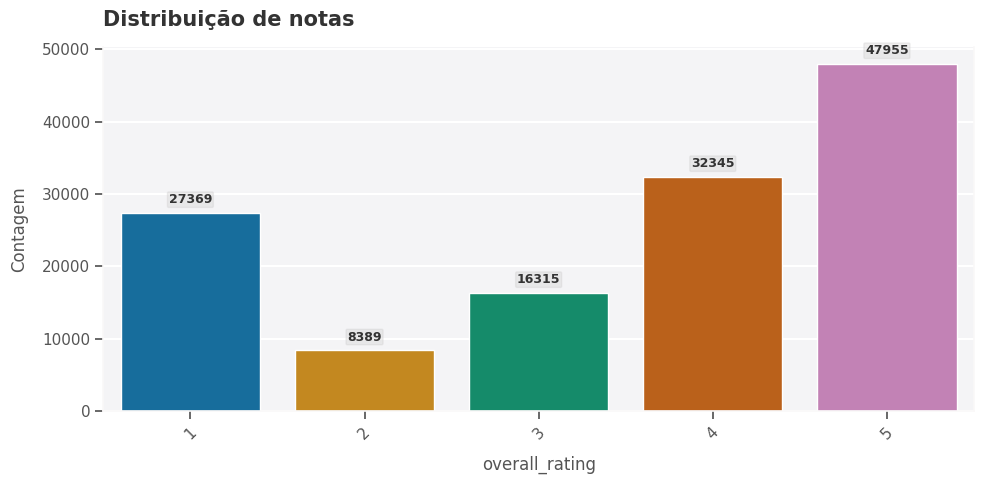

In [8]:
criar_grafico(df=df_reviews, tipo='count', col_x='overall_rating', titulo='Distribuição de notas')

In [9]:
def rating_to_label(r):
    if r <= 2:   return 'negativo'
    elif r == 3: return 'neutro'
    else:        return 'positivo'

df_reviews['sentimento_pela_nota'] = df_reviews['overall_rating'].apply(rating_to_label)
print(df_reviews['sentimento_pela_nota'].value_counts())

sentimento_pela_nota
positivo    80300
negativo    35758
neutro      16315
Name: count, dtype: int64


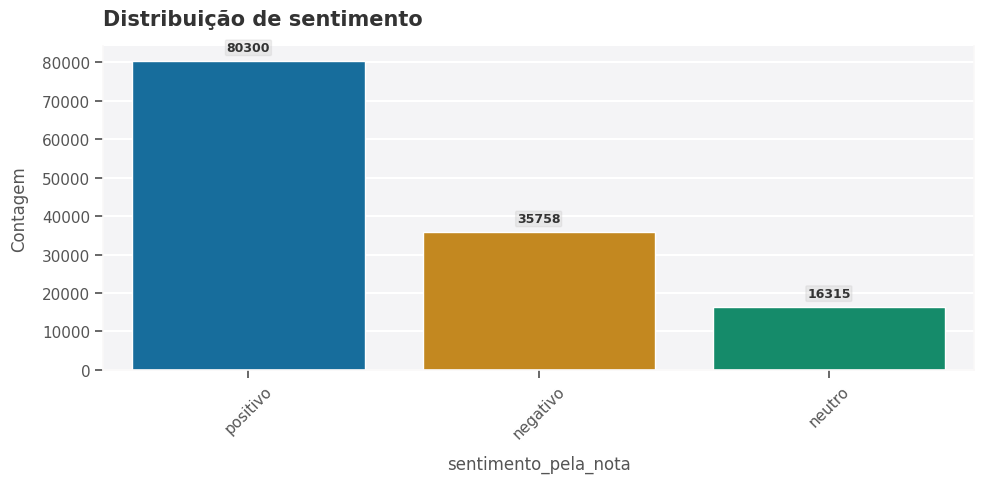

In [10]:
criar_grafico(df=df_reviews, tipo='count', col_x='sentimento_pela_nota', titulo='Distribuição de sentimento')

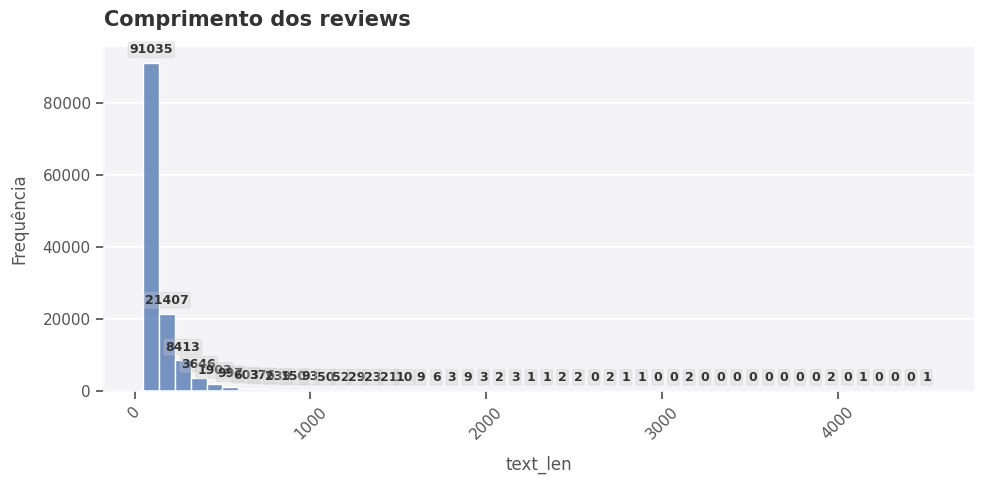

In [11]:
df_reviews['text_len'] = df_reviews['review_text'].dropna().apply(len)
criar_grafico(df=df_reviews, tipo='hist', col_x='text_len', titulo='Comprimento dos reviews', bins=50)

In [12]:
df_reviews['review_title_text_complete'] = df_reviews['review_title'].fillna('') + ' ' + df_reviews['review_text'].fillna('')
df_reviews['review_title_text_complete'] = df_reviews['review_title_text_complete'].str.strip()
df_reviews['review_title_text_complete'] = df_reviews['review_title_text_complete'].replace('', np.nan)

df_reviews.head()

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state,sentimento_pela_nota,text_len,review_title_text_complete
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ,positivo,158.0,Bom Estou contente com a compra entrega rápida...
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC,positivo,69.0,"Preço imbatível, ótima qualidade Por apenas R$..."
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP,positivo,236.0,ATENDE TODAS AS EXPECTATIVA. SUPERA EM AGILIDA...
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP,positivo,62.0,presente mais que desejado MEU FILHO AMOU! PAR...
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG,positivo,202.0,"Sem duvidas, excelente A entrega foi no prazo,..."


In [13]:
STOPWORDS_PT = set(stopwords.words('portuguese'))

def limpar_texto(texto):
    if pd.isna(texto):
        return ''
    texto = texto.lower()
    texto = re.sub(r'http\S+', '', texto)        # remove URLs
    texto = re.sub(r'[^a-záàâãéèêíóôõúç0-9\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = texto.split()
    tokens = [t for t in tokens if t not in STOPWORDS_PT and len(t) > 2]

    return ' '.join(tokens)

df_reviews['review_limpa_completa'] = df_reviews['review_title_text_complete'].apply(limpar_texto)
df_reviews['review_limpa_completa'] = df_reviews['review_limpa_completa'].replace('', np.nan)


In [14]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   submission_date             132373 non-null  object 
 1   reviewer_id                 132373 non-null  object 
 2   product_id                  132373 non-null  object 
 3   product_name                132289 non-null  object 
 4   product_brand               40982 non-null   object 
 5   site_category_lv1           132367 non-null  object 
 6   site_category_lv2           128360 non-null  object 
 7   review_title                132070 non-null  object 
 8   overall_rating              132373 non-null  int64  
 9   recommend_to_a_friend       132355 non-null  object 
 10  review_text                 129098 non-null  object 
 11  reviewer_birth_year         126389 non-null  float64
 12  reviewer_gender             128237 non-null  object 
 13  reviewer_state

In [15]:
df_reviews.query('review_text.isna()').head()

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state,sentimento_pela_nota,text_len,review_title_text_complete,review_limpa_completa
33,2018-01-01 05:27:25,0151593d73de9061b1b888d081ec4ed63f68ecae5853e5...,7502295,Moto Elétrica Infantil 6V Motocross Vermelha H...,NaN,Brinquedos,Mini Veículos,Péssimo produto e atendimento da lojas Americanas,1,No,NaN,1986.0,F,SP,negativo,NaN,Péssimo produto e atendimento da lojas Americanas,péssimo produto atendimento lojas americanas
41,2018-01-01 05:53:04,b4de8db318b92631f446ada4babaa9e8e2951c33e73f6c...,26992048,Lençol Avulso Com Elástico Solteiro 170 Fios P...,NaN,"Cama, Mesa e Banho",Lençol Avulso,Ótimo,4,Yes,NaN,1982.0,F,SP,positivo,NaN,Ótimo,ótimo
68,2018-01-01 06:21:55,92307e31233243e5a947e72993b5573d5bf60b2dd0db18...,20697582,Bicicleta Infantil Aro 20 Sport Bike Flowers C...,NaN,Brinquedos,Bicicleta Infantil,7,4,Yes,NaN,1958.0,M,SC,positivo,NaN,7,NaN
110,2018-01-01 06:56:31,c23bfb9f1549e390acc83c272acaf2349cd8ffa94e46c1...,19519597,Mesoestetic - Cosmelan 2,NaN,Saúde,NaN,Pessimo!!!,1,No,NaN,1981.0,F,SP,negativo,NaN,Pessimo!!!,pessimo
391,2018-01-01 12:39:30,517a17ba0b9c0b22f6797fc4343f78e8906f1aa2435b04...,28250567,Kit Automotivo Compressor de Ar + Aspirador de...,NaN,Automotivo,Limpeza de Automóveis,"NÃO RECEBI A MERCADORIA, ATÉ A PRESENTE DATA.",1,No,NaN,1952.0,M,RJ,negativo,NaN,"NÃO RECEBI A MERCADORIA, ATÉ A PRESENTE DATA.",recebi mercadoria presente data


In [16]:
df_reviews_limpo= df_reviews.dropna(subset=['review_limpa_completa'])

In [17]:
print(f'Dataset final: {len(df_reviews_limpo)} amostras')

Dataset final: 132211 amostras


In [18]:
# Balanceamento
min_count = df_reviews_limpo['sentimento_pela_nota'].value_counts().min()
df_bal = df_reviews_limpo.groupby('sentimento_pela_nota').apply(
    lambda x: x.sample(min_count, random_state=42)
).reset_index(drop=True)
print('Dataset balanceado:', df_bal['sentimento_pela_nota'].value_counts())

# Split treino / teste
X = df_bal['review_limpa_completa']
y = df_bal['sentimento_pela_nota']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

df_bal.to_csv('b2w_preprocessado_balanceado.csv', index=False)
print('Dados salvos em b2w_preprocessado.csv')

Dataset balanceado: sentimento_pela_nota
negativo    16293
neutro      16293
positivo    16293
Name: count, dtype: int64
Treino: 39103 | Teste: 9776
Dados salvos em b2w_preprocessado.csv


#3- Divisão Treino e Teste


In [97]:
df_train, df_test = train_test_split(
    df_bal, test_size=0.2, random_state=42, stratify=df_bal['sentimento_pela_nota']
)

X_train = df_train['review_limpa_completa']
X_test = df_test['review_limpa_completa']
y_train = df_train['sentimento_pela_nota']
y_test = df_test['sentimento_pela_nota']

print(f'Tamanho do conjunto de treino (df_train): {len(df_train)} amostras')
print(f'Tamanho do conjunto de teste (df_test): {len(df_test)} amostras')
print(f'Distribuição da variável target no treino:\n{y_train.value_counts(normalize=True)}')
print(f'Distribuição da variável target no teste:\n{y_test.value_counts(normalize=True)}')

df_train.to_csv('b2w_preprocessado_treino.csv', index=False)
df_test.to_csv('b2w_preprocessado_teste.csv', index=False)

Tamanho do conjunto de treino (df_train): 39103 amostras
Tamanho do conjunto de teste (df_test): 9776 amostras
Distribuição da variável target no treino:
sentimento_pela_nota
negativo    0.333350
positivo    0.333325
neutro      0.333325
Name: proportion, dtype: float64
Distribuição da variável target no teste:
sentimento_pela_nota
neutro      0.333367
positivo    0.333367
negativo    0.333265
Name: proportion, dtype: float64


#4- Teste 1: TF-IDF + SVM

## 4.1- Treinamneto e escolha dos parametros

In [98]:
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13})
os.makedirs('figuras', exist_ok=True)
os.makedirs('resultados', exist_ok=True)

RANDOM_STATE = 42
CLASSES      = ['negativo', 'neutro', 'positivo']
N_SEEDS      = 30   # 30 exe com dif seeds

In [99]:
# variação dos parametros a fim de comparação
CONFIGS = [
    # max_features, ngram_range,  C
    {'max_features':  5_000, 'ngram': (1,1), 'C': 0.1},
    {'max_features':  5_000, 'ngram': (1,1), 'C': 1.0},
    {'max_features':  5_000, 'ngram': (1,1), 'C': 10.0},
    {'max_features':  5_000, 'ngram': (1,2), 'C': 1.0},
    {'max_features': 10_000, 'ngram': (1,1), 'C': 0.1},
    {'max_features': 10_000, 'ngram': (1,1), 'C': 1.0},
    {'max_features': 10_000, 'ngram': (1,1), 'C': 10.0},
    {'max_features': 10_000, 'ngram': (1,2), 'C': 1.0},
    {'max_features': 10_000, 'ngram': (1,2), 'C': 10.0},
    {'max_features': 20_000, 'ngram': (1,1), 'C': 1.0},
    {'max_features': 20_000, 'ngram': (1,2), 'C': 1.0},
    {'max_features': 20_000, 'ngram': (1,2), 'C': 10.0},
]

In [100]:
resultados = []

for i, cfg in enumerate(CONFIGS):
    label_cfg = (f"feat={cfg['max_features']//1000}k "
                 f"ngram={'uni' if cfg['ngram']==(1,1) else 'bi'} "
                 f"C={cfg['C']}")

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=cfg['max_features'],
            ngram_range=cfg['ngram'],
            sublinear_tf=True,      # aplica log(tf) — melhora resultados
            min_df=2,               # ignora tokens que aparecem < 2x
            analyzer='word',
        )),
        ('svm', LinearSVC(
            C=cfg['C'],
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])

    # Treino
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t_treino = time.time() - t0

    # Inferência
    t1 = time.time()
    y_pred = pipe.predict(X_test)
    t_inf = time.time() - t1

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

    # F1 por classe
    f1_per = f1_score(y_test, y_pred, average=None,
                      labels=CLASSES, zero_division=0)

    resultados.append({
        'config'       : label_cfg,
        'max_features' : cfg['max_features'],
        'ngram'        : f"({cfg['ngram'][0]},{cfg['ngram'][1]})",
        'C'            : cfg['C'],
        'acuracia'     : round(acc,  4),
        'f1_macro'     : round(f1,   4),
        'precision'    : round(prec, 4),
        'recall'       : round(rec,  4),
        'f1_negativo'  : round(f1_per[0], 4),
        'f1_neutro'    : round(f1_per[1], 4),
        'f1_positivo'  : round(f1_per[2], 4),
        't_treino_s'   : round(t_treino, 3),
        't_inf_ms'     : round(t_inf * 1000, 2),
    })

    print(f"[{i+1:>2}/{len(CONFIGS)}] {label_cfg:<40} "
          f"F1={f1:.4f}  Acc={acc:.4f}  t={t_treino:.1f}s")

df_res_tf_idf = pd.DataFrame(resultados)

[ 1/12] feat=5k ngram=uni C=0.1                  F1=0.7479  Acc=0.7503  t=1.1s
[ 2/12] feat=5k ngram=uni C=1.0                  F1=0.7305  Acc=0.7324  t=1.7s
[ 3/12] feat=5k ngram=uni C=10.0                 F1=0.7130  Acc=0.7144  t=3.0s
[ 4/12] feat=5k ngram=bi C=1.0                   F1=0.7394  Acc=0.7406  t=2.8s
[ 5/12] feat=10k ngram=uni C=0.1                 F1=0.7471  Acc=0.7494  t=1.2s
[ 6/12] feat=10k ngram=uni C=1.0                 F1=0.7239  Acc=0.7259  t=1.7s
[ 7/12] feat=10k ngram=uni C=10.0                F1=0.6937  Acc=0.6945  t=3.8s
[ 8/12] feat=10k ngram=bi C=1.0                  F1=0.7343  Acc=0.7353  t=4.2s
[ 9/12] feat=10k ngram=bi C=10.0                 F1=0.7028  Acc=0.7028  t=4.2s
[10/12] feat=20k ngram=uni C=1.0                 F1=0.7248  Acc=0.7263  t=1.7s
[11/12] feat=20k ngram=bi C=1.0                  F1=0.7304  Acc=0.7313  t=6.4s
[12/12] feat=20k ngram=bi C=10.0                 F1=0.6870  Acc=0.6868  t=4.7s


In [101]:
df_res_tf_idf.to_csv('resultados/resultados_svm_params.csv', index=False)

In [102]:
df_res_tf_idf.head(12)

,config,max_features,ngram,C,acuracia,f1_macro,precision,recall,f1_negativo,f1_neutro,f1_positivo,t_treino_s,t_inf_ms
0,feat=5k ngram=uni C=0.1,5000,"(1,1)",0.1,0.7503,0.7479,0.7475,0.7503,0.8394,0.6400,0.7645,1.069,157.19
1,feat=5k ngram=uni C=1.0,5000,"(1,1)",1.0,0.7324,0.7305,0.7295,0.7324,0.8236,0.6195,0.7484,1.746,291.19
2,feat=5k ngram=uni C=10.0,5000,"(1,1)",10.0,0.7144,0.7130,0.7121,0.7144,0.8028,0.6009,0.7353,3.029,170.07
3,feat=5k ngram=bi C=1.0,5000,"(1,2)",1.0,0.7406,0.7394,0.7387,0.7406,0.8319,0.6341,0.7522,2.784,261.03
4,feat=10k ngram=uni C=0.1,10000,"(1,1)",0.1,0.7494,0.7471,0.7467,0.7494,0.8386,0.6393,0.7633,1.152,215.33
5,feat=10k ngram=uni C=1.0,10000,"(1,1)",1.0,0.7259,0.7239,0.7228,0.7259,0.8190,0.6105,0.7423,1.651,217.45
6,feat=10k ngram=uni C=10.0,10000,"(1,1)",10.0,0.6945,0.6937,0.6931,0.6945,0.7872,0.5825,0.7114,3.832,323.22
7,feat=10k ngram=bi C=1.0,10000,"(1,2)",1.0,0.7353,0.7343,0.7336,0.7353,0.8281,0.6283,0.7465,4.164,318.18
8,feat=10k ngram=bi C=10.0,10000,"(1,2)",10.0,0.7028,0.7028,0.7028,0.7029,0.7953,0.5962,0.7169,4.166,294.64
9,feat=20k ngram=uni C=1.0,20000,"(1,1)",1.0,0.7263,0.7248,0.7240,0.7263,0.8193,0.6135,0.7417,1.695,214.25


Escolha do melhor parametro, olhando para o f1_macro:
 A escolha é pelo F1-macro porque é a métrica que trata as 3 classes com peso igual —se olhasse só acurácia, um modelo que acerta todos os positivos e erra todos os negativos pareceria bom.


In [103]:

melhor_idx = df_res_tf_idf['f1_macro'].idxmax()
melhor     = df_res_tf_idf.iloc[melhor_idx]
print(f"\nMelhor configuração: {melhor['config']}")
print(f"  F1-macro  : {melhor['f1_macro']:.4f}")
print(f"  Acurácia  : {melhor['acuracia']:.4f}")
print(f"  Precision : {melhor['precision']:.4f}")
print(f"  Recall    : {melhor['recall']:.4f}")


Melhor configuração: feat=5k ngram=uni C=0.1
  F1-macro  : 0.7479
  Acurácia  : 0.7503
  Precision : 0.7475
  Recall    : 0.7503


## 4.2- Treinamendo com configuração escolhida

In [104]:
# Treinar melhor modelo
best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=int(melhor['max_features']),
        ngram_range=eval(melhor['ngram']),
        sublinear_tf=True,
        min_df=2,
    )),
    ('svm', LinearSVC(C=melhor['C'], max_iter=3000, random_state=RANDOM_STATE))
])
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)

print("\nRelatório de classificação completo:")
print(classification_report(y_test, y_pred_best,
                             target_names=CLASSES, digits=4))


Relatório de classificação completo:
              precision    recall  f1-score   support

    negativo     0.8006    0.8821    0.8394      3258
      neutro     0.6580    0.6229    0.6400      3259
    positivo     0.7839    0.7459    0.7645      3259

    accuracy                         0.7503      9776
   macro avg     0.7475    0.7503    0.7479      9776
weighted avg     0.7475    0.7503    0.7479      9776



##4.3- Exec 30 seeds

In [119]:
mf_best = int(melhor['max_features'])
ng_best = eval(melhor['ngram'])
c_best  = melhor['C']

f1_seeds  = []
acc_seeds = []
t_seeds   = []

# Concatena UMA VEZ fora do loop (mais eficiente também)
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([pd.Series(y_train), pd.Series(y_test)], ignore_index=True)

for seed in range(N_SEEDS):
    X_tr, X_ts, y_tr, y_ts = train_test_split(
        X_all, y_all,
        test_size=0.2,
        random_state=seed,
        stratify=y_all
    )
    p = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=mf_best, ngram_range=ng_best,
            sublinear_tf=True, min_df=2
        )),
        ('svm', LinearSVC(C=c_best, max_iter=3000, random_state=seed))
    ])
    t0 = time.time()
    p.fit(X_tr, y_tr)
    t_seeds.append(time.time() - t0)
    yp = p.predict(X_ts)
    f1_seeds.append(f1_score(y_ts, yp, average='macro'))
    acc_seeds.append(accuracy_score(y_ts, yp))

In [120]:
df_seeds.to_csv('resultados/resultados_svm_30seeds.csv', index=False)

In [106]:
df_seeds.head(30)

,seed,f1_macro,acuracia,tempo_s
0,0,0.746197,0.748159,1.050811
1,1,0.746534,0.748670,1.000666
2,2,0.754834,0.756751,0.965324
3,3,0.752309,0.754296,0.971733
4,4,0.746700,0.748773,0.973493
5,5,0.749136,0.751534,1.025824
6,6,0.755496,0.756751,1.424805
7,7,0.751761,0.753376,1.523441
8,8,0.745413,0.747443,1.339862
9,9,0.742985,0.745192,1.041255


In [107]:
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

cv_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=mf_best, ngram_range=ng_best,
        sublinear_tf=True, min_df=2
    )),
    ('svm', LinearSVC(C=c_best, max_iter=3000, random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1  = cross_val_score(cv_pipe, X_all, y_all,
                          cv=cv, scoring='f1_macro', n_jobs=-1)
cv_acc = cross_val_score(cv_pipe, X_all, y_all,
                          cv=cv, scoring='accuracy', n_jobs=-1)

print(f"F1-macro  CV: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  {cv_f1.round(4)}")
print(f"Acurácia  CV: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}  {cv_acc.round(4)}")

F1-macro  CV: 0.7504 ± 0.0034  [0.7538 0.7453 0.7536 0.7478 0.7516]
Acurácia  CV: 0.7526 ± 0.0033  [0.7561 0.7474 0.7551 0.7503 0.7542]


## 4.4- Analise Final

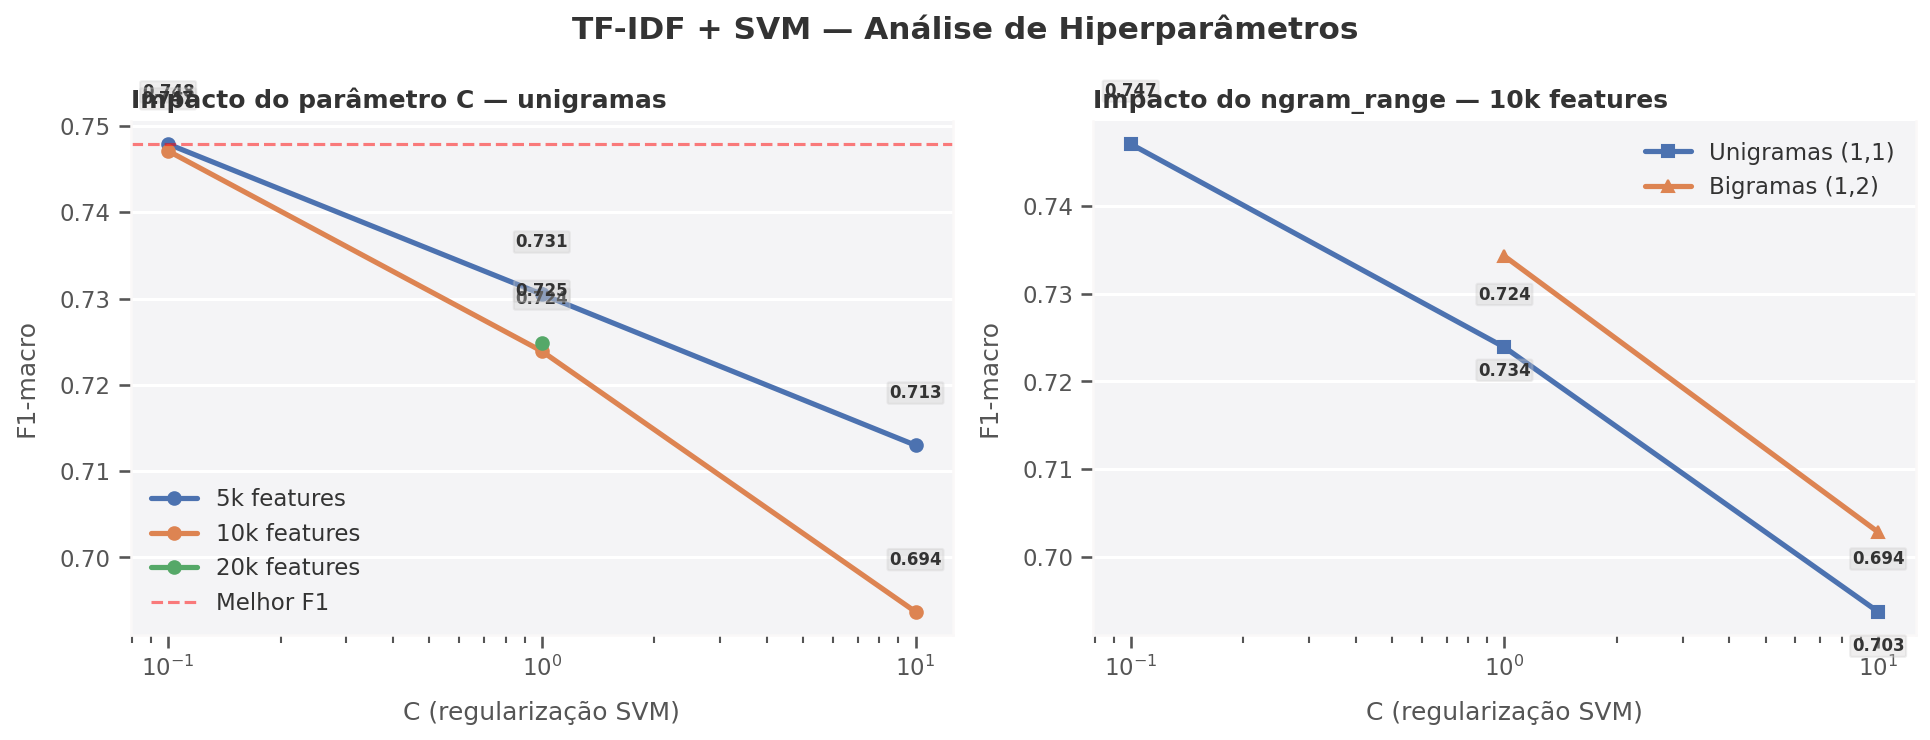

Salvo: figuras/fig_svm_params.png


In [108]:
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico esquerdo: F1 × C, separado por max_features (só unigramas)
for i, mf in enumerate([5000, 10000, 20000]):
    cor = paleta_padrao[i % len(paleta_padrao)]
    sub = df_res_tf_idf[(df_res_tf_idf['max_features'] == mf) & (df_res_tf_idf['ngram'] == '(1,1)')]
    if len(sub):
        axes1[0].plot(sub['C'], sub['f1_macro'], marker='o', markersize=6, linewidth=2.5, label=f'{mf//1000}k features', color=cor)
        for x, y in zip(sub['C'], sub['f1_macro']):
            axes1[0].text(x, y + 0.005, f'{y:.3f}', color="#333333", ha='center', va='bottom', fontsize=8, fontweight='bold', bbox=estilo_caixa)

axes1[0].set_xscale('log')
axes1[0].set_xlabel('C (regularização SVM)', labelpad=10)
axes1[0].set_ylabel('F1-macro', labelpad=10)
axes1[0].set_title('Impacto do parâmetro C — unigramas', fontweight="bold", loc='left', fontsize=12)
axes1[0].axhline(melhor['f1_macro'], color='red', linestyle='--', alpha=0.5, label='Melhor F1')
axes1[0].legend(frameon=False, loc='best')

# Gráfico direito: comparação uni vs bigrama para 10k features
sub_uni = df_res_tf_idf[(df_res_tf_idf['max_features'] == 10000) & (df_res_tf_idf['ngram'] == '(1,1)')]
sub_bi  = df_res_tf_idf[(df_res_tf_idf['max_features'] == 10000) & (df_res_tf_idf['ngram'] == '(1,2)')]

axes1[1].plot(sub_uni['C'], sub_uni['f1_macro'], marker='s', markersize=6, linewidth=2.5, label='Unigramas (1,1)', color=paleta_padrao[0])
for x, y in zip(sub_uni['C'], sub_uni['f1_macro']):
    axes1[1].text(x, y + 0.005, f'{y:.3f}', color="#333333", ha='center', va='bottom', fontsize=8, fontweight='bold', bbox=estilo_caixa)

axes1[1].plot(sub_bi['C'], sub_bi['f1_macro'], marker='^', markersize=6, linewidth=2.5, label='Bigramas (1,2)', color=paleta_padrao[1])
for x, y in zip(sub_bi['C'], sub_bi['f1_macro']):
    axes1[1].text(x, y - 0.012, f'{y:.3f}', color="#333333", ha='center', va='top', fontsize=8, fontweight='bold', bbox=estilo_caixa)

axes1[1].set_xscale('log')
axes1[1].set_xlabel('C (regularização SVM)', labelpad=10)
axes1[1].set_ylabel('F1-macro', labelpad=10)
axes1[1].set_title('Impacto do ngram_range — 10k features', fontweight="bold", loc='left', fontsize=12)
axes1[1].legend(frameon=False, loc='best')

plt.suptitle('TF-IDF + SVM — Análise de Hiperparâmetros', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('figuras/fig_svm_params.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: figuras/fig_svm_params.png")

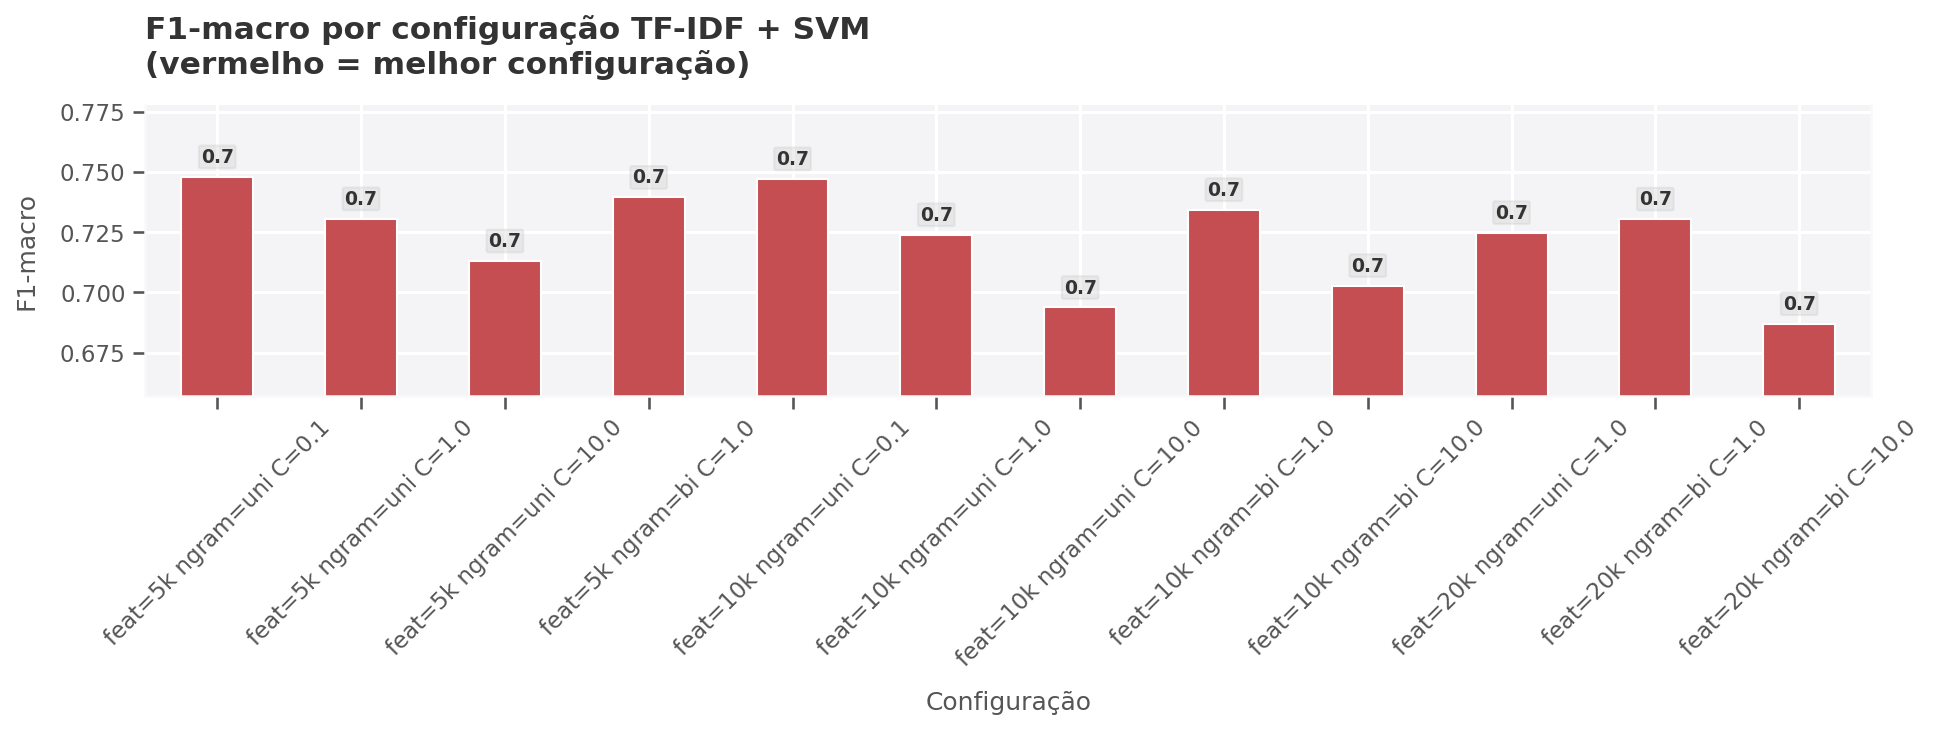

Salvo: figuras/fig_svm_configs.png


<Figure size 960x720 with 0 Axes>

In [109]:
# Definindo as cores dinâmicas (vermelho para o melhor, azul padrão para o resto)
cores_config = ['#c44e52' if i == melhor_idx else paleta_padrao[0] for i in range(len(df_res_tf_idf))]

criar_grafico(
    df=df_res_tf_idf,
    col_x='config',
    cols_y=['f1_macro'],
    tipo='barra',
    titulo='F1-macro por configuração TF-IDF + SVM\n(vermelho = melhor configuração)',
    xlabel='Configuração',
    ylabel='F1-macro',
    paleta=cores_config,
    ylim=(df_res_tf_idf['f1_macro'].min() - 0.03, df_res_tf_idf['f1_macro'].max() + 0.03),
    figsize=(13, 5)
)

# Como a função dá plt.show(), salvamos logo em seguida se necessário reexibir, ou salve antes editando a função.
# Para garantir o salvamento exato do arquivo do seu script:
plt.gcf().savefig('figuras/fig_svm_configs.png', dpi=150, bbox_inches='tight')
print("Salvo: figuras/fig_svm_configs.png")

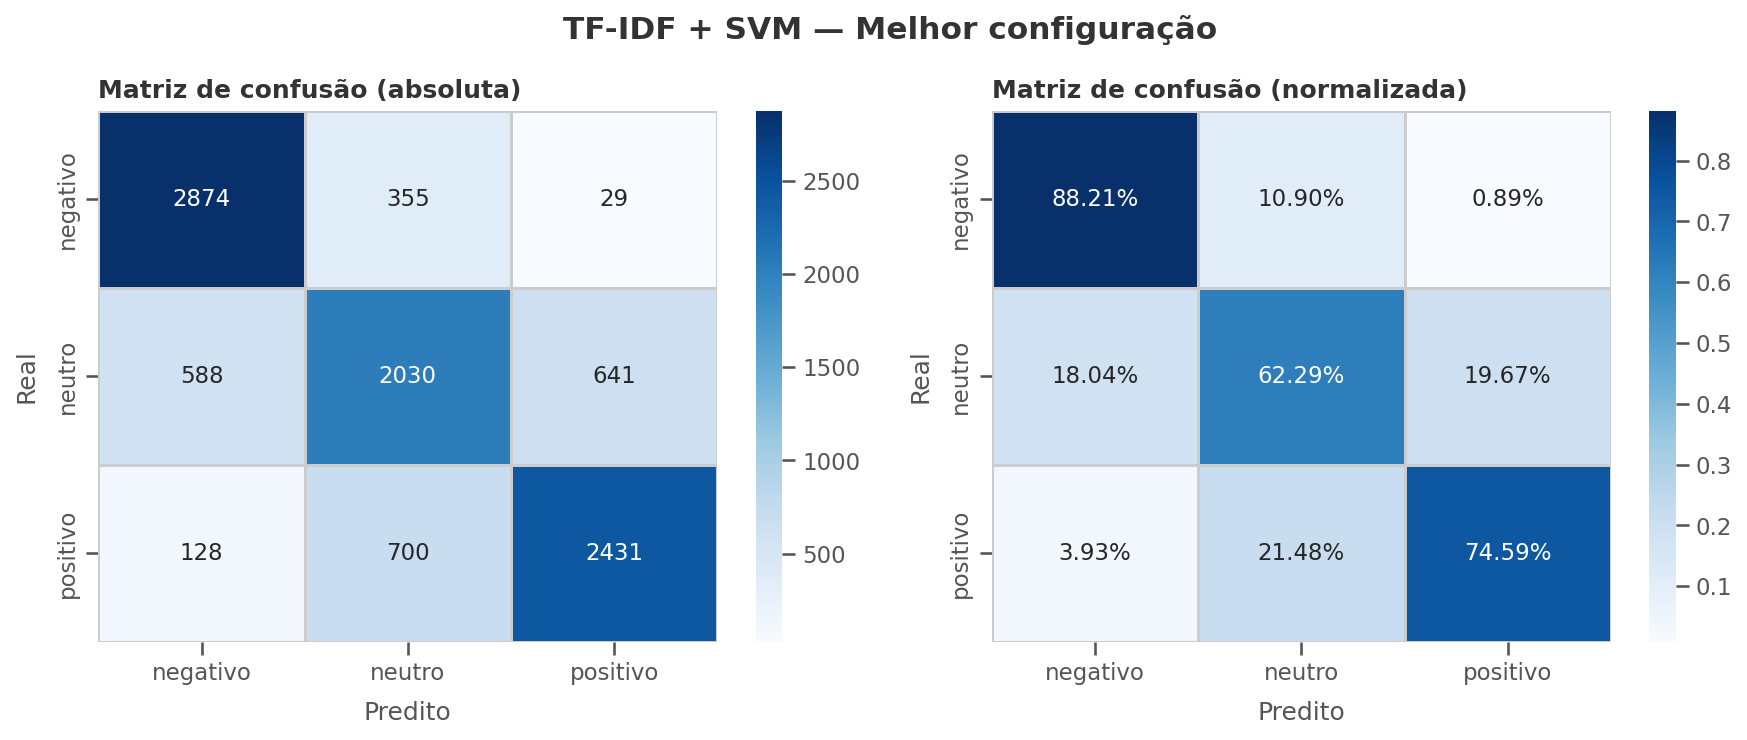

Salvo: figuras/fig_svm_cm.png


In [110]:
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, y_pred_best, labels=CLASSES)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Absoluta (Estilo Heatmap da sua função)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes3[0], linewidths=.5, linecolor='#CCCCCC')
axes3[0].set_title('Matriz de confusão (absoluta)', fontweight="bold", loc='left', fontsize=12)
axes3[0].set_xlabel('Predito', labelpad=8)
axes3[0].set_ylabel('Real', labelpad=8)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes3[1], linewidths=.5, linecolor='#CCCCCC')
axes3[1].set_title('Matriz de confusão (normalizada)', fontweight="bold", loc='left', fontsize=12)
axes3[1].set_xlabel('Predito', labelpad=8)
axes3[1].set_ylabel('Real', labelpad=8)

plt.suptitle('TF-IDF + SVM — Melhor configuração', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('figuras/fig_svm_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: figuras/fig_svm_cm.png")

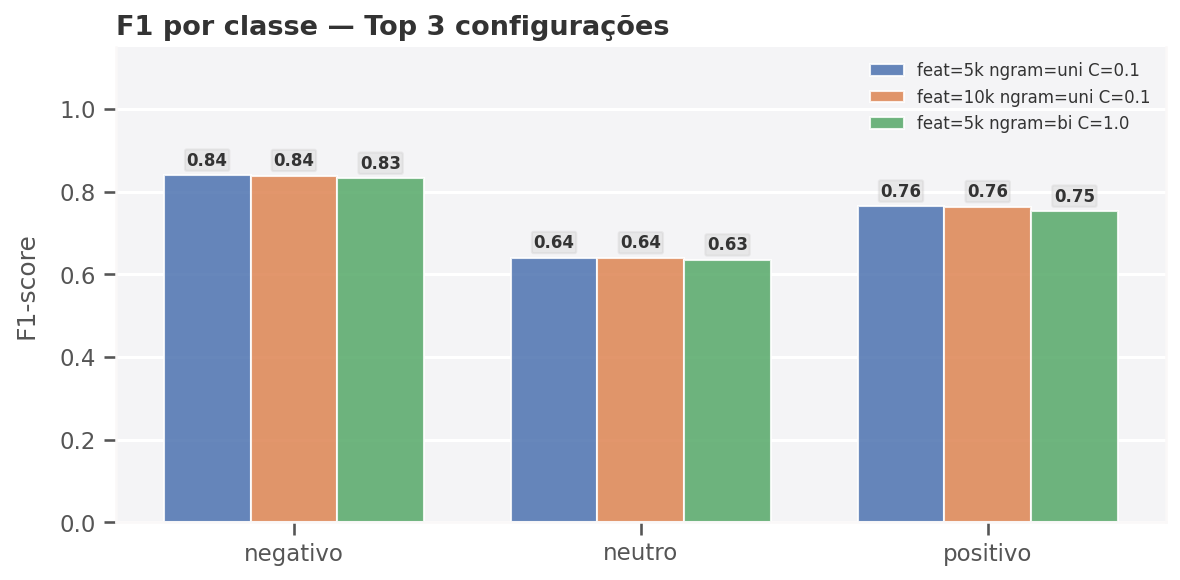

Salvo: figuras/fig_svm_f1_por_classe.png


In [111]:
fig4, ax4 = plt.subplots(figsize=(8, 4))
x = np.arange(len(CLASSES))
width = 0.25

top3_idx = df_res_tf_idf['f1_macro'].nlargest(3).index
for k, (idx, cor) in enumerate(zip(top3_idx, paleta_padrao[:3])):
    vals = [df_res_tf_idf.loc[idx, f'f1_{c}'] for c in CLASSES]
    rects = ax4.bar(x + k*width, vals, width, label=df_res_tf_idf.loc[idx,'config'], color=cor, alpha=0.85)
    ax4.bar_label(rects, fmt='%.2f', padding=3, color="#333333", fontweight='bold', fontsize=8, bbox=estilo_caixa)

ax4.set_xticks(x + width)
ax4.set_xticklabels(CLASSES)
ax4.set_ylabel('F1-score', labelpad=10)
ax4.set_title('F1 por classe — Top 3 configurações', fontweight="bold", loc='left', fontsize=13)
ax4.legend(frameon=False, fontsize=8)
ax4.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('figuras/fig_svm_f1_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: figuras/fig_svm_f1_por_classe.png")

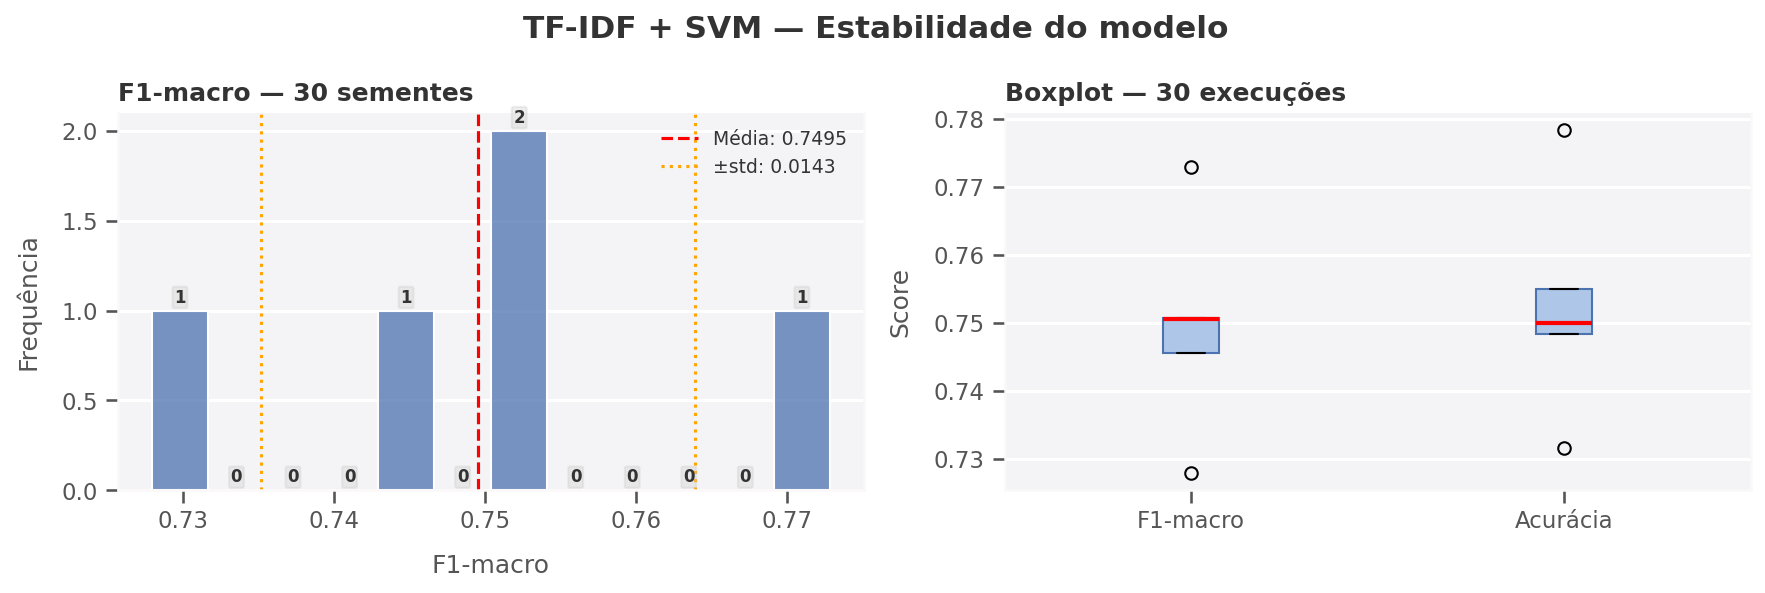

Salvo: figuras/fig_svm_seeds.png


In [112]:
fig5, axes5 = plt.subplots(1, 2, figsize=(12, 4))

# Lado Esquerdo: Histograma padronizado com sns.histplot (igual adicionamos na sua função)
sns.histplot(x=f1_arr, bins=12, color=paleta_padrao[0], ax=axes5[0], kde=False)
for container in axes5[0].containers:
    axes5[0].bar_label(container, padding=2, color="#333333", fontweight='bold', fontsize=8, bbox=estilo_caixa)

axes5[0].axvline(f1_arr.mean(), color='red', linestyle='--', label=f'Média: {f1_arr.mean():.4f}')
axes5[0].axvline(f1_arr.mean() - f1_arr.std(), color='orange', linestyle=':', label=f'±std: {f1_arr.std():.4f}')
axes5[0].axvline(f1_arr.mean() + f1_arr.std(), color='orange', linestyle=':')
axes5[0].set_xlabel('F1-macro', labelpad=10)
axes5[0].set_ylabel('Frequência', labelpad=10)
axes5[0].set_title(f'F1-macro — {N_SEEDS} sementes', fontweight="bold", loc='left', fontsize=12)
axes5[0].legend(frameon=False, fontsize=9)

# Lado Direito: Boxplot
axes5[1].boxplot([f1_arr, acc_arr], labels=['F1-macro', 'Acurácia'], patch_artist=True,
                 boxprops=dict(facecolor='#aec7e8', edgecolor=paleta_padrao[0]),
                 medianprops=dict(color='red', linewidth=2))
axes5[1].set_ylabel('Score', labelpad=10)
axes5[1].set_title(f'Boxplot — {N_SEEDS} execuções', fontweight="bold", loc='left', fontsize=12)

plt.suptitle('TF-IDF + SVM — Estabilidade do modelo', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('figuras/fig_svm_seeds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: figuras/fig_svm_seeds.png")

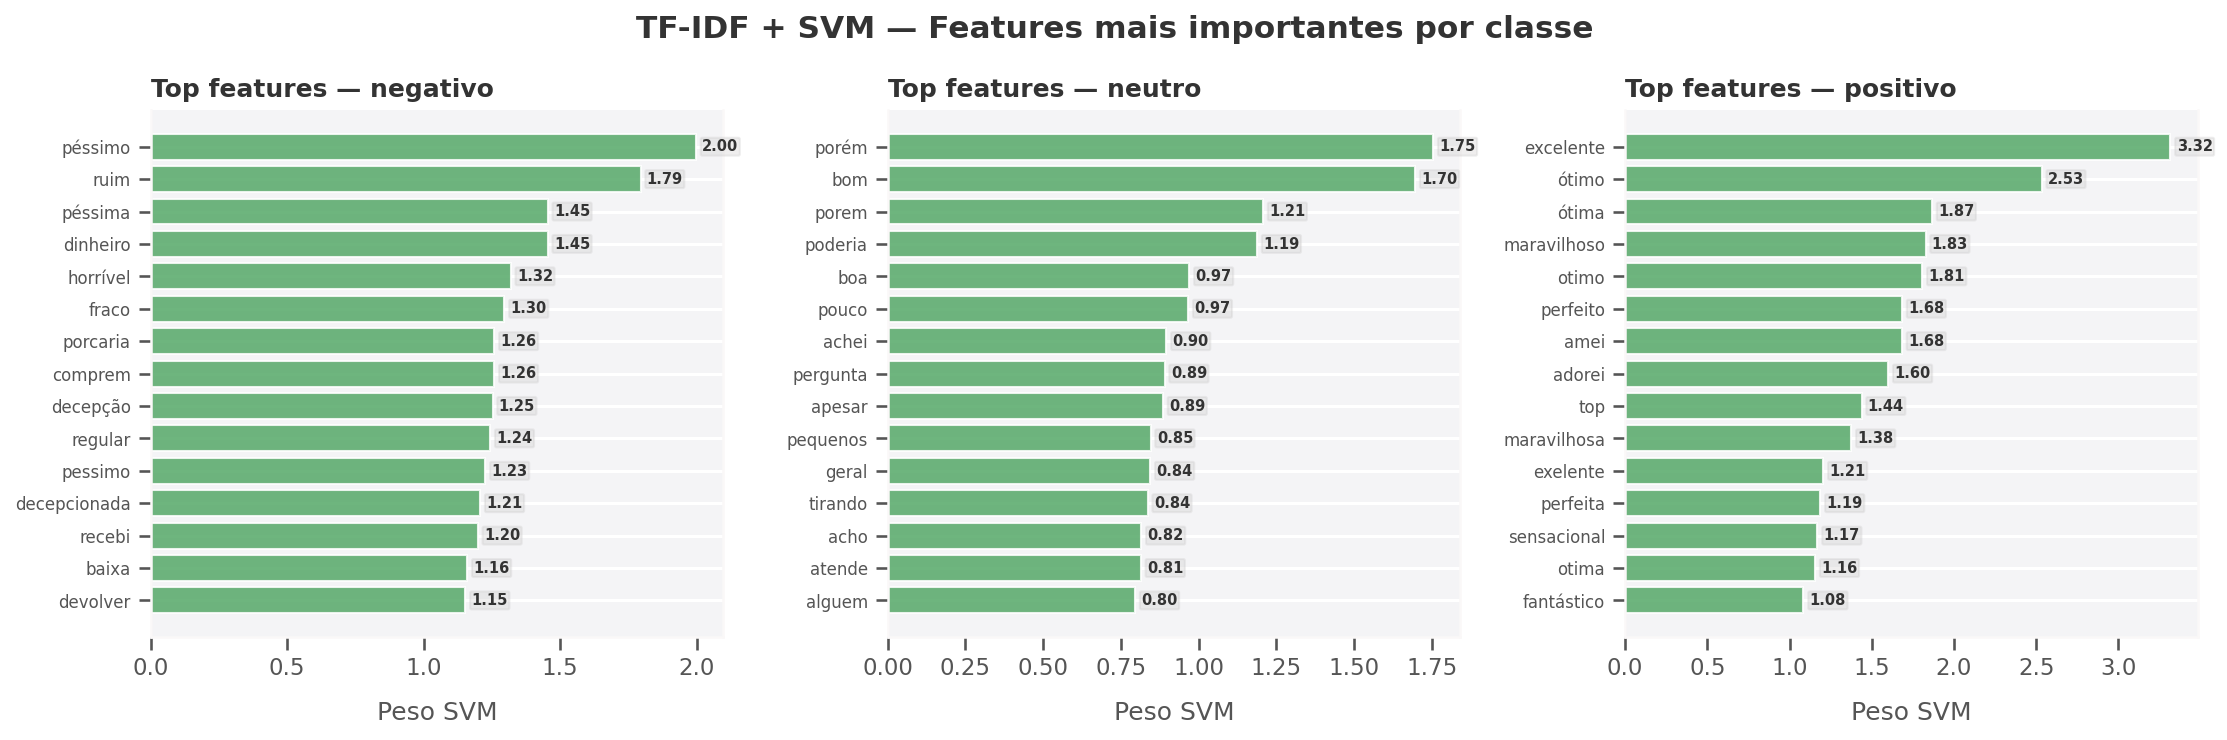

Salvo: figuras/fig_svm_features.png


In [113]:
try:
    best_tfidf = best_pipe.named_steps['tfidf']
    best_svm   = best_pipe.named_steps['svm']
    feature_names = np.array(best_tfidf.get_feature_names_out())

    fig7, axes7 = plt.subplots(1, 3, figsize=(15, 5))
    n_top = 15

    for ax, classe, coef in zip(axes7, CLASSES, best_svm.coef_):
        top_idx = np.argsort(coef)[-n_top:]
        top_feats = feature_names[top_idx]
        top_coefs = coef[top_idx]
        cores_feat = ['#c44e52' if c < 0 else '#55a868' for c in top_coefs]

        rects = ax.barh(range(n_top), top_coefs, color=cores_feat, alpha=0.85)
        ax.set_yticks(range(n_top))
        ax.set_yticklabels(top_feats, fontsize=8)
        ax.set_title(f'Top features — {classe}', fontweight="bold", loc='left', fontsize=12)
        ax.set_xlabel('Peso SVM', labelpad=10)
        ax.axvline(0, color='black', linewidth=0.5)

        # Adicionando rótulos com caixinhas cinzas nas barras horizontais
        ax.bar_label(rects, fmt='%.2f', padding=3, color="#333333", fontweight='bold', fontsize=7, bbox=estilo_caixa)

    plt.suptitle('TF-IDF + SVM — Features mais importantes por classe', fontweight='bold', fontsize=15)
    plt.tight_layout()
    plt.savefig('figuras/fig_svm_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Salvo: figuras/fig_svm_features.png")
except Exception as e:
    print(f"Não foi possível gerar fig de features: {e}")

In [114]:
erros_df = df_test.copy()
erros_df['predito'] = y_pred_best
erros_df['correto'] = (erros_df['sentimento_pela_nota'] == erros_df['predito'])

print("\n--- Exemplos de erros por tipo ---")
for real in CLASSES:
    for pred in CLASSES:
        if real == pred:
            continue
        sub = erros_df[(erros_df['sentimento_pela_nota'] == real) & (erros_df['predito'] == pred)]
        if len(sub) > 0:
            print(f"\n  Real={real} → Predito={pred} ({len(sub)} casos)")
            amostra = sub['review_limpa_completa'].sample(min(2, len(sub)), random_state=42).values
            for txt in amostra:
                print(f"    » {txt[:100]}")

print("\n--- Taxa de erro por classe ---")
for c in CLASSES:
    sub = erros_df[erros_df['sentimento_pela_nota'] == c]
    taxa = 1 - sub['correto'].mean()
    print(f"  {c:<12}: {taxa:.2%} de erro ({int(taxa*len(sub))} / {len(sub)})")


--- Exemplos de erros por tipo ---

  Real=negativo → Predito=neutro (355 casos)
    » descrever melhor aparelhos pois produto usado deveria ter classificação estado encontra acordo uso b
    » decepcionei descrição dizia medidas porém prática avaliar achei tapete fininho pequeno praticar yoga

  Real=negativo → Predito=positivo (29 casos)
    » bom ótimo produto qualidade excelente super indico ficou ótimo instalação obrigado tudo pois comprar
    » nota zero vou saber bom dia receber faz hoje dias compra eninguém sabe dizer onde telefone admira em

  Real=neutro → Predito=negativo (588 casos)
    » parte eletrônica danificada fios desconectados peças soltas dentro levar eletrônica consertar
    » parece monitor bem pequena parece monitor computador visibilidade somente frente ficar pouco abaixo 

  Real=neutro → Predito=positivo (641 casos)
    » perfume sutil sempre entrega rápida perfume sentir cheiro antes comprar vezes compra preço conta pod
    » bom produto bom sim forte brilh

In [115]:
tabela_ieee = pd.DataFrame([{
    'Modelo'        : 'TF-IDF + SVM',
    'Configuração'  : melhor['config'],
    'Acurácia'      : f"{melhor['acuracia']:.4f}",
    'F1-macro'      : f"{melhor['f1_macro']:.4f}",
    'Precision'     : f"{melhor['precision']:.4f}",
    'Recall'        : f"{melhor['recall']:.4f}",
    'F1 (neg)'      : f"{melhor['f1_negativo']:.4f}",
    'F1 (neu)'      : f"{melhor['f1_neutro']:.4f}",
    'F1 (pos)'      : f"{melhor['f1_positivo']:.4f}",
    'Tempo treino'  : f"{melhor['t_treino_s']:.3f}s",
    'Tempo inf.'    : f"{melhor['t_inf_ms']:.2f}ms",
    'F1 30-seeds μ' : f"{f1_arr.mean():.4f}",
    'F1 30-seeds σ' : f"{f1_arr.std():.4f}",
    'F1 CV 5-fold'  : f"{cv_f1.mean():.4f} ± {cv_f1.std():.4f}",
}])
tabela_ieee.head()

,Modelo,Configuração,Acurácia,F1-macro,Precision,Recall,F1 (neg),F1 (neu),F1 (pos),Tempo treino,Tempo inf.,F1 30-seeds μ,F1 30-seeds σ,F1 CV 5-fold
0,TF-IDF + SVM,feat=5k ngram=uni C=0.1,0.7503,0.7479,0.7475,0.7503,0.8394,0.6400,0.7645,1.069s,157.19ms,0.7495,0.0143,0.7504 ± 0.0034


In [116]:
tabela_ieee.to_csv('resultados/tabela_ieee_svm.csv')

In [117]:
erros_df.head()

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state,sentimento_pela_nota,text_len,review_title_text_complete,review_limpa_completa,predito,correto
17927,2018-05-18 16:36:03,e1faa900e80beceee42e44daa505edcb16ce769ab0418d...,15971292,Fechadura Externa - 2600/71 - Aliança,NaN,Ferramentas e Jardim,NaN,Gostei muito do produto.,3,Yes,"Fechadura simples mas de boa qualidade, gostei...",1961.0,F,SP,neutro,69.0,Gostei muito do produto. Fechadura simples mas...,gostei produto fechadura simples boa qualidade...,neutro,True
32617,2018-03-26 19:23:40,bbc85895a2b706f176b4c964bc33b84bce2082af6dd6cd...,126430671,Lavadora de Roupas Consul 16kg CWL16 Branca,consul,Eletrodomésticos,Máquina de Lavar e Tanquinho,excelente lavadora,5,Yes,"lavadora cumpre o que promete, excelente custo...",1963.0,M,SP,positivo,57.0,excelente lavadora lavadora cumpre o que prome...,excelente lavadora lavadora cumpre promete exc...,positivo,True
1895,2018-05-18 08:51:40,73398a1b94f6f60e2adf339c3265aee61c37989fbfd84e...,24996174,Balança Digital de Banheiro 180 KG Vidro Tempe...,NaN,Saúde,Higiene Pessoal,Médio,2,No,Não tem instruções em Português e demora na en...,1969.0,F,DF,negativo,51.0,Médio Não tem instruções em Português e demora...,médio instruções português demora entrega,negativo,True
20506,2018-02-26 16:01:54,4b2fa76ed31a53b600f7dd701f48a30e0e69c9e9c61cba...,130918531,Smartphone Samsung Galaxy A7 Dual Chip Android...,samsung,Celulares e Smartphones,Smartphone,Bom produto,3,Yes,Gostei e recomendo para os clientes que ainda ...,1975.0,M,RJ,neutro,69.0,Bom produto Gostei e recomendo para os cliente...,bom produto gostei recomendo clientes ainda dú...,neutro,True
19968,2018-03-12 19:56:47,f568776c6c5092a512cc546557d447d0dffa8e29ac9aa2...,111586438,Depilador Elétrico Philips Satinelle HP6403/30,philips,Beleza e Perfumaria,Depilação,"Muito bom, gostei muito.",3,Yes,"O produto atende as necessidades, dói um pouco...",1981.0,M,SP,neutro,90.0,"Muito bom, gostei muito. O produto atende as n...",bom gostei produto atende necessidades dói pou...,neutro,True


#5- Teste 2: LSTM com Keras

In [43]:
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13})
os.makedirs('figuras', exist_ok=True)
os.makedirs('resultados', exist_ok=True)

RANDOM_STATE = 42
CLASSES= ['negativo', 'neutro', 'positivo']
N_SEEDS= 30
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

##5.1- Tokenização + padding

In [44]:
X_train_raw = df_train['review_limpa_completa'].fillna('').values
X_test_raw  = df_test['review_limpa_completa'].fillna('').values
y_train_raw = df_train['sentimento_pela_nota'].values
y_test_raw  = df_test['sentimento_pela_nota'].values

In [45]:
TAM_VOCAB = 20_000   #tamanho do vocabulario
MAX_LEN = 100

tokenizer = Tokenizer(
    num_words=TAM_VOCAB,
    oov_token='<OOV>',   #substitui palavras desconhecidas
    lower=True,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(X_train_raw)   #indice p treino

#apenas os 20000 + freq sendo configurados
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulário aprendido: {len(tokenizer.word_index)} tokens únicos")
print(f"MAX_LEN = {MAX_LEN} tokens")

seq_lens = [len(s) for s in X_train_seq]
print(f"\nComprimento das sequências:")
print(f"  Mediana : {np.median(seq_lens):.0f}")
print(f"  Média   : {np.mean(seq_lens):.0f}")
print(f"  P90     : {np.percentile(seq_lens, 90):.0f}")
print(f"  P99     : {np.percentile(seq_lens, 99):.0f}")
print(f"  Máximo  : {np.max(seq_lens)}")

Vocabulário aprendido: 35640 tokens únicos
MAX_LEN = 100 tokens

Comprimento das sequências:
  Mediana : 12
  Média   : 16
  P90     : 29
  P99     : 66
  Máximo  : 544




*   Olhando para as metricas, o MAX_LEN=100 ta ok, ao menos 99% dos comentarios estao dentro



In [46]:
label_enc = LabelEncoder()
label_enc.fit(CLASSES)

y_train = label_enc.transform(y_train_raw)
y_test  = label_enc.transform(y_test_raw)

y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=3)

print(f"Mapeamento das classes: {dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_)))}")
print(f"y_train binário shape: {y_train_cat.shape}")
print(f"y_test  binário shape: {y_test_cat.shape}")

Mapeamento das classes: {np.str_('negativo'): np.int64(0), np.str_('neutro'): np.int64(1), np.str_('positivo'): np.int64(2)}
y_train binário shape: (39103, 3)
y_test  binário shape: (9776, 3)


In [47]:
def build_lstm(
    vocab_size   = TAM_VOCAB,
    embed_dim    = 64,
    lstm_units   = 128,
    dropout_rate = 0.3,
    max_len      = MAX_LEN,
    bidirectional= False,
    num_classes  = 3,
):
    """Gera e compila a rede neural recorrente de classificação de sentimentos."""
    inputs = keras.Input(shape=(max_len,), name='input_tokens')
    x = layers.Embedding(
        input_dim    = vocab_size + 1,
        output_dim   = embed_dim,
        mask_zero    = True,
        name         = 'embedding'
    )(inputs)

    lstm_layer = layers.LSTM(lstm_units, name='lstm')
    if bidirectional:
        x = layers.Bidirectional(lstm_layer, name='bilstm')(x)
    else:
        x = lstm_layer(x)

    x = layers.Dropout(dropout_rate, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='lstm_sentiment')
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=1e-3),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return model

model_demo = build_lstm()
model_demo.summary()

Model: "lstm_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_tokens        │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │  1,280,064 │ input_tokens[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ input_tokens[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     98,816 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,379,267 (5.26 MB)

 Trainable params: 1,379,267 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

* Embedding: vetores numéricos onde palavras com o mesmo sentido próximas

* LSTM: rede de memória de curto e longo prazo que varre a sequência de palavras, entendendo a ordem e o contexto

* Dropout e Dense: desconecta sinapses aleatoriamente no treino para impedir a rede de "decorar" o dataset

##5.2- Treinamento e escolha de parametros


In [48]:
CONFIGS = [
    {'embed_dim':  32, 'lstm_units':  64, 'dropout': 0.2, 'bi': False, 'label': 'emb32 · lstm64  · drop0.2'},
    {'embed_dim':  64, 'lstm_units':  64, 'dropout': 0.2, 'bi': False, 'label': 'emb64 · lstm64  · drop0.2'},
    {'embed_dim':  64, 'lstm_units': 128, 'dropout': 0.2, 'bi': False, 'label': 'emb64 · lstm128 · drop0.2'},
    {'embed_dim':  64, 'lstm_units': 128, 'dropout': 0.3, 'bi': False, 'label': 'emb64 · lstm128 · drop0.3'},
    {'embed_dim':  64, 'lstm_units': 128, 'dropout': 0.5, 'bi': False, 'label': 'emb64 · lstm128 · drop0.5'},
    {'embed_dim': 128, 'lstm_units': 128, 'dropout': 0.3, 'bi': False, 'label': 'emb128 · lstm128 · drop0.3'},
    {'embed_dim': 128, 'lstm_units': 256, 'dropout': 0.3, 'bi': False, 'label': 'emb128 · lstm256 · drop0.3'},
    {'embed_dim':  64, 'lstm_units': 128, 'dropout': 0.3, 'bi': True,  'label': 'emb64 · BiLSTM128 · drop0.3'},
    {'embed_dim': 128, 'lstm_units': 128, 'dropout': 0.3, 'bi': True,  'label': 'emb128 · BiLSTM128 · drop0.3'},
]

EPOCHS     = 10
BATCH_SIZE = 128

print("\n" + "=" * 60)
print("3. EXPERIMENTOS COM VARIAÇÃO DE PARÂMETROS")
print(f"   {len(CONFIGS)} configs × {EPOCHS} épocas × batch={BATCH_SIZE}")
print("=" * 60)

resultados  = []
historicos  = {}

for i, cfg in enumerate(CONFIGS):
    print(f"\n[{i+1}/{len(CONFIGS)}] {cfg['label']}")

    tf.random.set_seed(RANDOM_STATE)
    model = build_lstm(
        embed_dim    = cfg['embed_dim'],
        lstm_units   = cfg['lstm_units'],
        dropout_rate = cfg['dropout'],
        bidirectional= cfg['bi'],
    )

    # EarlyStopping interrompe se o modelo parar de melhorar na validação por 3 épocas consecutivas
    early_stop = callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = 3,
        restore_best_weights = True,
        verbose              = 0
    )

    t0 = time.time()
    history = model.fit(
        X_train_pad, y_train_cat,
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE,
        validation_split= 0.15,      # Reserva 15% do treino para testes internos de validação
        callbacks       = [early_stop],
        verbose         = 0
    )
    t_treino = time.time() - t0
    epocas_reais = len(history.history['loss'])

    # Predição nos dados de validação de teste
    t1 = time.time()
    y_prob = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0)
    t_inf = time.time() - t1
    y_pred = np.argmax(y_prob, axis=1)
    y_pred_labels = label_enc.inverse_transform(y_pred)

    # Computação rigorosa de métricas estatísticas
    acc    = accuracy_score(y_test_raw,  y_pred_labels)
    f1     = f1_score(y_test_raw,  y_pred_labels, average='macro')
    prec   = precision_score(y_test_raw, y_pred_labels, average='macro', zero_division=0)
    rec    = recall_score(y_test_raw,  y_pred_labels, average='macro', zero_division=0)
    f1_per = f1_score(y_test_raw, y_pred_labels, average=None, labels=CLASSES, zero_division=0)

    historicos[cfg['label']] = history.history
    resultados.append({
        'config'       : cfg['label'], 'embed_dim'    : cfg['embed_dim'],
        'lstm_units'   : cfg['lstm_units'], 'dropout'      : cfg['dropout'],
        'bidirectional': cfg['bi'], 'epocas_reais' : epocas_reais,
        'acuracia'     : round(acc,  4), 'f1_macro'     : round(f1,   4),
        'precision'    : round(prec, 4), 'recall'       : round(rec,  4),
        'f1_negativo'  : round(f1_per[0], 4), 'f1_neutro'    : round(f1_per[1], 4),
        'f1_positivo'  : round(f1_per[2], 4), 't_treino_s'   : round(t_treino, 1),
        't_inf_ms'     : round(t_inf * 1000, 1),
    })
    print(f"    → épocas_reais={epocas_reais}  F1-Macro={f1:.4f}  Acurácia={acc:.4f}  Tempo={t_treino:.1f}s")


3. EXPERIMENTOS COM VARIAÇÃO DE PARÂMETROS
   9 configs × 10 épocas × batch=128

[1/9] emb32 · lstm64  · drop0.2
    → épocas_reais=4  F1-Macro=0.7504  Acurácia=0.7504  Tempo=22.1s

[2/9] emb64 · lstm64  · drop0.2
    → épocas_reais=4  F1-Macro=0.7514  Acurácia=0.7503  Tempo=13.5s

[3/9] emb64 · lstm128 · drop0.2
    → épocas_reais=4  F1-Macro=0.7506  Acurácia=0.7525  Tempo=14.3s

[4/9] emb64 · lstm128 · drop0.3
    → épocas_reais=4  F1-Macro=0.7471  Acurácia=0.7491  Tempo=17.7s

[5/9] emb64 · lstm128 · drop0.5
    → épocas_reais=4  F1-Macro=0.7487  Acurácia=0.7516  Tempo=17.2s

[6/9] emb128 · lstm128 · drop0.3
    → épocas_reais=4  F1-Macro=0.7534  Acurácia=0.7533  Tempo=14.9s

[7/9] emb128 · lstm256 · drop0.3
    → épocas_reais=4  F1-Macro=0.7529  Acurácia=0.7545  Tempo=15.4s

[8/9] emb64 · BiLSTM128 · drop0.3
    → épocas_reais=4  F1-Macro=0.7581  Acurácia=0.7580  Tempo=17.4s

[9/9] emb128 · BiLSTM128 · drop0.3
    → épocas_reais=4  F1-Macro=0.7618  Acurácia=0.7619  Tempo=19.7s


In [49]:
df_res_lstm = pd.DataFrame(resultados)
df_res_lstm.to_csv('resultados/resultados_lstm_params.csv', index=False)

In [50]:
df_res_lstm.head()

,config,embed_dim,lstm_units,dropout,bidirectional,epocas_reais,acuracia,f1_macro,precision,recall,f1_negativo,f1_neutro,f1_positivo,t_treino_s,t_inf_ms
0,emb32 · lstm64 · drop0.2,32,64,0.2,False,4,0.7504,0.7504,0.7513,0.7504,0.8399,0.6503,0.7610,22.1,574.6
1,emb64 · lstm64 · drop0.2,64,64,0.2,False,4,0.7503,0.7514,0.7549,0.7503,0.8438,0.6576,0.7530,13.5,574.8
2,emb64 · lstm128 · drop0.2,64,128,0.2,False,4,0.7525,0.7506,0.7496,0.7525,0.8446,0.6411,0.7660,14.3,573.0
3,emb64 · lstm128 · drop0.3,64,128,0.3,False,4,0.7491,0.7471,0.7466,0.7491,0.8433,0.6378,0.7602,17.7,916.8
4,emb64 · lstm128 · drop0.5,64,128,0.5,False,4,0.7516,0.7487,0.7475,0.7516,0.8450,0.6340,0.7672,17.2,618.6


##5.3- Treinamento com escolha definitiva

In [52]:
melhor_idx = df_res_lstm['f1_macro'].idxmax()
melhor_cfg = CONFIGS[melhor_idx]
melhor     = df_res_lstm.iloc[melhor_idx]
print(f"\nMelhor configuração detectada na busca: {melhor['config']}")

tf.random.set_seed(RANDOM_STATE)
best_model = build_lstm(
    embed_dim    = melhor_cfg['embed_dim'],
    lstm_units   = melhor_cfg['lstm_units'],
    dropout_rate = melhor_cfg['dropout'],
    bidirectional= melhor_cfg['bi'],
)

early_stop_best = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

best_history = best_model.fit(
    X_train_pad, y_train_cat,
    epochs           = 20,
    batch_size       = BATCH_SIZE,
    validation_split = 0.15,
    callbacks        = [early_stop_best],
    verbose          = 1
)

y_prob_best   = best_model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0)
y_pred_best   = np.argmax(y_prob_best, axis=1)
y_pred_labels_best = label_enc.inverse_transform(y_pred_best)

print("\nRelatório de Classificação Completo: ")
print(classification_report(y_test_raw, y_pred_labels_best, target_names=CLASSES, digits=4))


Melhor configuração detectada na busca: emb128 · BiLSTM128 · drop0.3
Epoch 1/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7333 - loss: 0.6289 - val_accuracy: 0.7595 - val_loss: 0.5601
Epoch 2/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8049 - loss: 0.4705 - val_accuracy: 0.7523 - val_loss: 0.5867
Epoch 3/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8384 - loss: 0.3972 - val_accuracy: 0.7349 - val_loss: 0.6543
Epoch 4/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8686 - loss: 0.3375 - val_accuracy: 0.7233 - val_loss: 0.7365
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Relatório de Classificação Completo: 
              precision    recall  f1-score   support

    negativo     0.8265    0.8772    0.8511      3258
      neutro     0.6562    0.6760    0.6660      3259
    positivo     0.8018    0.7284    0.7633      3259

    accuracy                         0.7605      9776
   macro avg     0.

##5.4- Exec 30 seeds

In [53]:
f1_seeds, acc_seeds, t_seeds = [], [], []
X_all = np.concatenate([X_train_pad, X_test_pad], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

for seed in range(N_SEEDS):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    X_tr, X_ts, y_tr_raw, y_ts_raw = train_test_split(
        X_all, y_all, test_size=0.2, random_state=seed, stratify=y_all
    )
    y_tr_cat = keras.utils.to_categorical(label_enc.transform(y_tr_raw), num_classes=3)

    m = build_lstm(
        embed_dim    = melhor_cfg['embed_dim'],
        lstm_units   = melhor_cfg['lstm_units'],
        dropout_rate = melhor_cfg['dropout'],
        bidirectional= melhor_cfg['bi'],
    )
    es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)

    t0 = time.time()
    m.fit(X_tr, y_tr_cat, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.15, callbacks=[es], verbose=0)
    t_seeds.append(time.time() - t0)

    y_ts_pred = label_enc.inverse_transform(np.argmax(m.predict(X_ts, verbose=0), axis=1))
    f1_seeds.append(f1_score(y_ts_raw, y_ts_pred, average='macro'))
    acc_seeds.append(accuracy_score(y_ts_raw, y_ts_pred))

    if (seed + 1) % 5 == 0:
        print(f"  Progresso: {seed+1}/{N_SEEDS} — Último F1 Alcançado: {f1_seeds[-1]:.4f}")

f1_arr, acc_arr = np.array(f1_seeds), np.array(acc_seeds)
pd.DataFrame({'seed': range(N_SEEDS), 'f1_macro': f1_arr, 'acuracia': acc_arr, 'tempo_s' : t_seeds}).to_csv('resultados/resultados_lstm_30seeds.csv', index=False)

  Progresso: 5/30 — Último F1 Alcançado: 0.7606
  Progresso: 10/30 — Último F1 Alcançado: 0.7539
  Progresso: 15/30 — Último F1 Alcançado: 0.7592
  Progresso: 20/30 — Último F1 Alcançado: 0.7586
  Progresso: 25/30 — Último F1 Alcançado: 0.7648
  Progresso: 30/30 — Último F1 Alcançado: 0.7641


##5.5- Analise Final

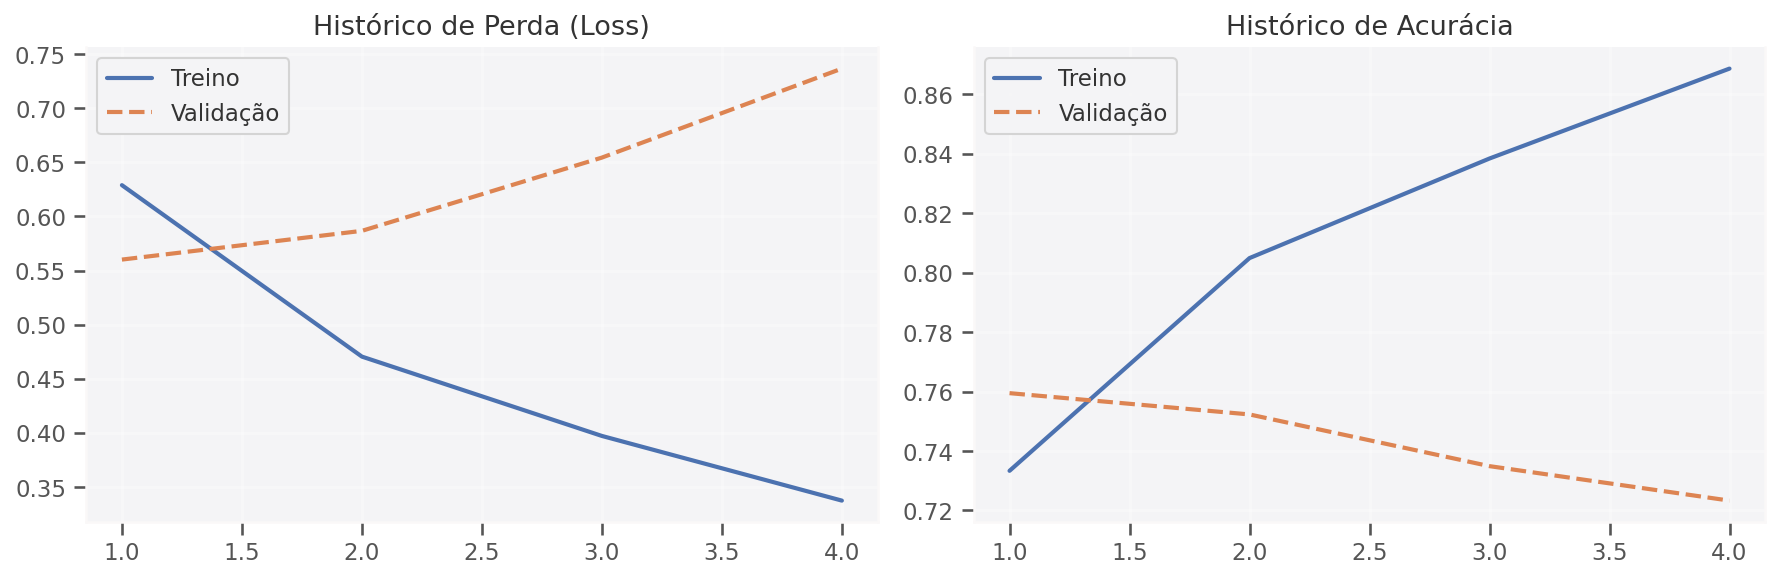

In [54]:
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(best_history.history['loss']) + 1)
axes1[0].plot(epochs_range, best_history.history['loss'], label='Treino', color='#4c72b0', linewidth=2)
axes1[0].plot(epochs_range, best_history.history['val_loss'], label='Validação', color='#dd8452', linewidth=2, linestyle='--')
axes1[0].set_title('Histórico de Perda (Loss)')
axes1[0].legend()
axes1[0].grid(True, alpha=0.3)

axes1[1].plot(epochs_range, best_history.history['accuracy'], label='Treino', color='#4c72b0', linewidth=2)
axes1[1].plot(epochs_range, best_history.history['val_accuracy'], label='Validação', color='#dd8452', linewidth=2, linestyle='--')
axes1[1].set_title('Histórico de Acurácia')
axes1[1].legend()
axes1[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/fig_lstm_learning_curves.png', dpi=150)
plt.show()


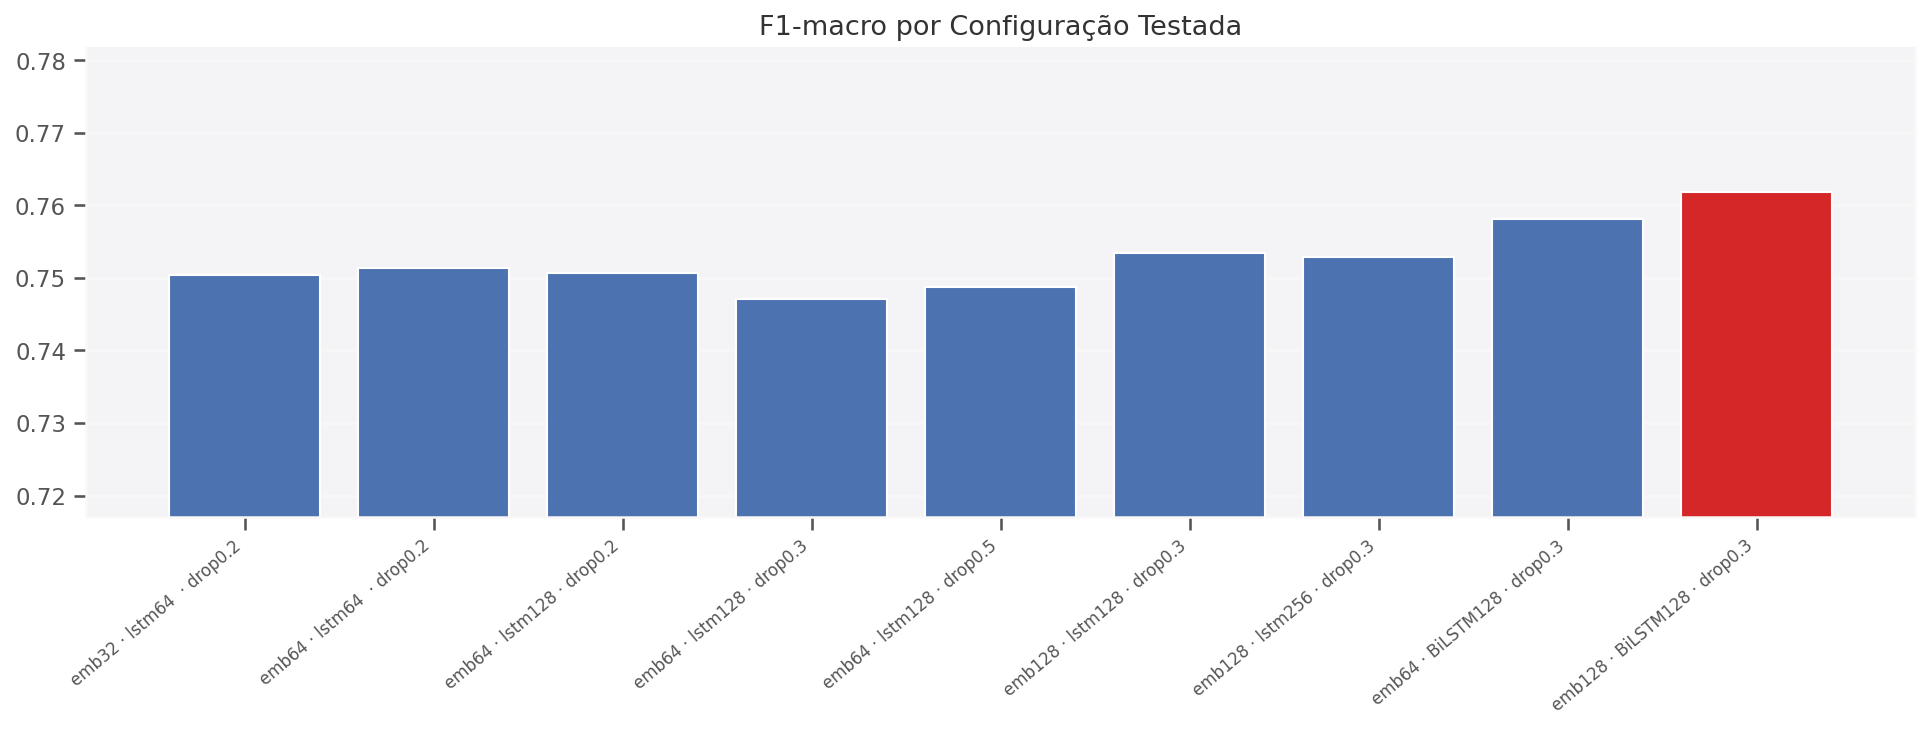

In [56]:
fig3, ax3 = plt.subplots(figsize=(13, 5))
cores = ['#d62728' if i == melhor_idx else '#4c72b0' for i in range(len(df_res_lstm))]
bars = ax3.bar(range(len(df_res_lstm)), df_res_lstm['f1_macro'], color=cores)
ax3.set_xticks(range(len(df_res_lstm)))
ax3.set_xticklabels(df_res_lstm['config'], rotation=40, ha='right', fontsize=8)
ax3.set_title('F1-macro por Configuração Testada')
ax3.set_ylim(df_res_lstm['f1_macro'].min() - 0.03, df_res_lstm['f1_macro'].max() + 0.02)
ax3.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/fig_lstm_f1_configs.png', dpi=150)
plt.show()


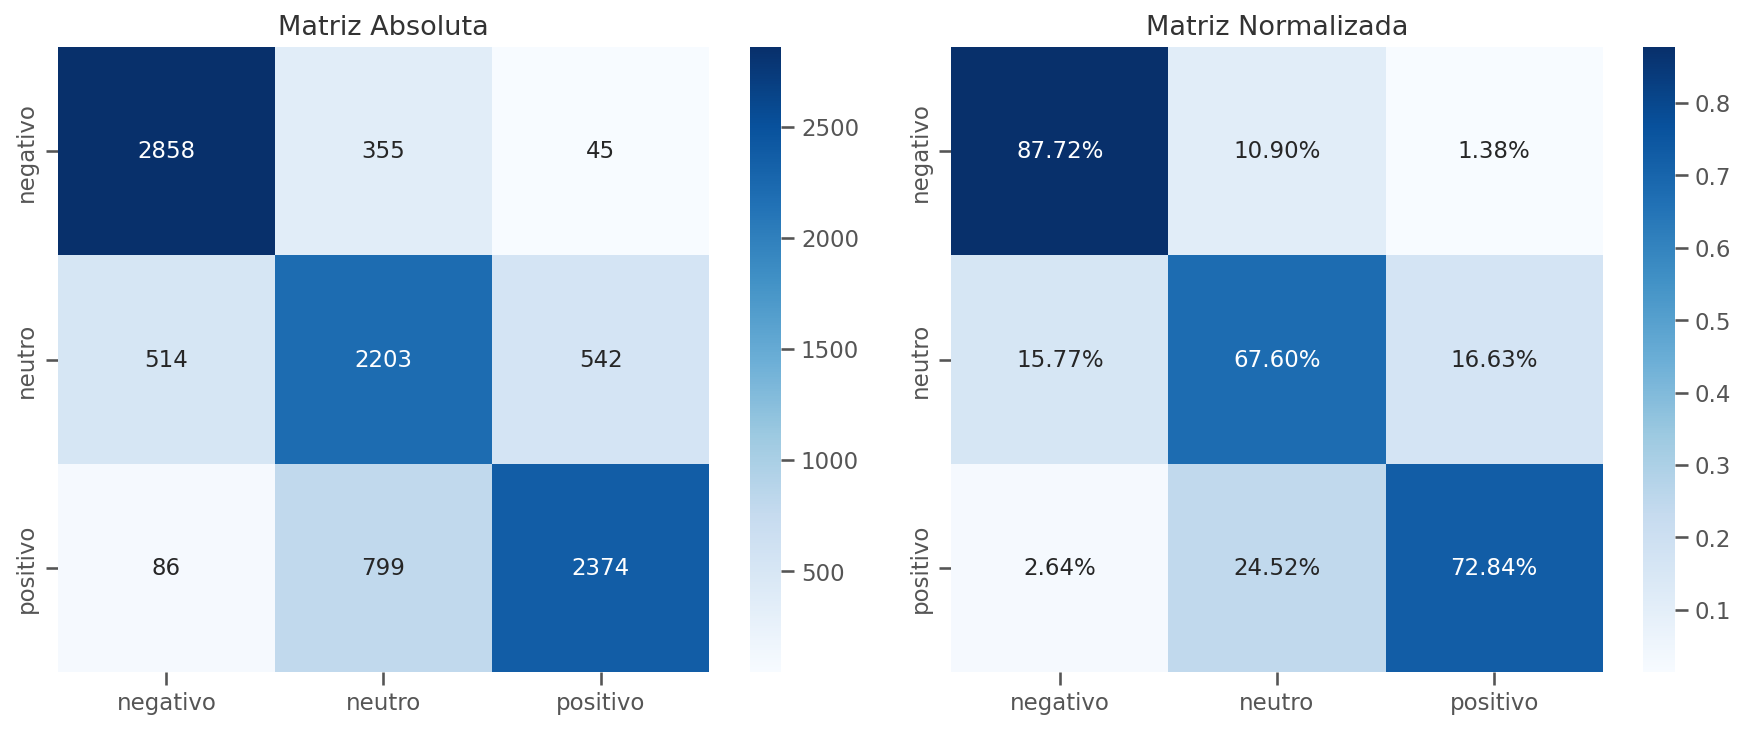

In [57]:
fig6, axes6 = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test_raw, y_pred_labels_best, labels=CLASSES)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes6[0])
axes6[0].set_title('Matriz Absoluta')
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes6[1])
axes6[1].set_title('Matriz Normalizada')
plt.tight_layout()
plt.savefig('figuras/fig_lstm_cm.png', dpi=150)
plt.show()

In [58]:
erros_df = df_test.copy()
erros_df['predito'] = y_pred_labels_best
erros_df['correto'] = erros_df['sentimento_pela_nota'] == erros_df['predito']
erros_df['confianca'] = np.max(y_prob_best, axis=1)

print("\n--- Erros com maior nível de confiança (Onde a rede errou estando segura de si) ---")
erros_conf = erros_df[~erros_df['correto']].nlargest(5, 'confianca')
for _, row in erros_conf.iterrows():
    print(f"\n  Real={row['sentimento_pela_nota']} → Predito={row['predito']} (Confiança interna={row['confianca']:.2%})")
    print(f"  » Texto: {str(row['review_limpa_completa'])[:100]}")

# Exportações para estruturação do relatório acadêmico (Molde de Tabela de Artigos IEEE)
tabela_ieee = pd.DataFrame([{
    'Modelo'        : 'LSTM', 'Configuração'  : melhor['config'],
    'Acurácia'      : f"{melhor['acuracia']:.4f}", 'F1-macro'      : f"{melhor['f1_macro']:.4f}",
    'Precision'     : f"{melhor['precision']:.4f}", 'Recall'        : f"{melhor['recall']:.4f}",
    'F1 (neg)'      : f"{melhor['f1_negativo']:.4f}", 'F1 (neu)'      : f"{melhor['f1_neutro']:.4f}",
    'F1 (pos)'      : f"{melhor['f1_positivo']:.4f}", 'Épocas'        : int(melhor['epocas_reais']),
    'Tempo treino'  : f"{melhor['t_treino_s']:.1f}s", 'Tempo inf.'    : f"{melhor['t_inf_ms']:.1f}ms",
    'F1 30-seeds μ' : f"{f1_arr.mean():.4f}", 'F1 30-seeds σ' : f"{f1_arr.std():.4f}",
}])

tabela_ieee.to_csv('resultados/tabela_ieee_lstm.csv', index=False)
erros_df.to_csv('resultados/predicoes_lstm.csv', index=False)
best_model.save('resultados/best_lstm_model.keras')
print("\n[Sucesso] Todos os dados salvos em 'resultados/' e 'figuras/'!")


--- Erros com maior nível de confiança (Onde a rede errou estando segura de si) ---

  Real=neutro → Predito=negativo (Confiança interna=99.81%)
  » Texto: reembolso produto esperava devolvi faz semana obtive resposta dinheiro volta

  Real=positivo → Predito=negativo (Confiança interna=99.69%)
  » Texto: recebi avaliar algo recebi solicitei cancelamento estorno valor pago

  Real=positivo → Predito=negativo (Confiança interna=99.64%)
  » Texto: péssimo fornecedor cancelaram compra muitos dias esperando devolveram dinheiro deixando crédito futu

  Real=negativo → Predito=positivo (Confiança interna=99.50%)
  » Texto: excelente material excelente qualidade recomendo todos amei

  Real=neutro → Predito=negativo (Confiança interna=99.49%)
  » Texto: recebi produto recebi produto encaminhei vários email obtive resposta faz mês comprei produto acompa

[Sucesso] Todos os dados salvos em 'resultados/' e 'figuras/'!


Olhando para esses erros acho q podemos relacionar com o que o autor disse sobre as notas nem sempre condizerem com o texto

#6- Teste 3: BERTimbau

In [63]:
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13})
os.makedirs('figuras', exist_ok=True)
os.makedirs('resultados', exist_ok=True)
RANDOM_STATE = 42
CLASSES= ['negativo', 'neutro', 'positivo']
LABEL2ID= {c: i for i, c in enumerate(CLASSES)}
ID2LABEL= {i: c for c, i in LABEL2ID.items()}
MODEL_NAME= 'neuralmind/bert-base-portuguese-cased'
set_seed(RANDOM_STATE)

In [65]:
if 'review_text' in df_train.columns:
    X_train_raw = df_train['review_text'].fillna(df_train['review_limpa_completa']).astype(str).values
    X_test_raw  = df_test['review_text'].fillna(df_test['review_limpa_completa']).astype(str).values
else:
    # Fallback caso seu CSV de treino só tenha a coluna limpa
    X_train_raw = df_train['review_limpa_completa'].astype(str).values
    X_test_raw  = df_test['review_limpa_completa'].astype(str).values

y_train_raw = df_train['sentimento_pela_nota'].values
y_test_raw  = df_test['sentimento_pela_nota'].values

y_train = np.array([LABEL2ID[y] for y in y_train_raw])
y_test  = np.array([LABEL2ID[y] for y in y_test_raw])

print(f"Treino : {len(X_train_raw):,} amostras")
print(f"Teste  : {len(X_test_raw):,}  amostras")

Treino : 39,103 amostras
Teste  : 9,776  amostras


##6.1- Tokenização

In [66]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocabulário nativo do BERTimbau: {tokenizer.vocab_size:,} tokens")
MAX_LEN = 128
exemplo = X_train_raw[0]
tokens_exemplo = tokenizer.tokenize(exemplo)
print(f"\nExemplo prático de quebra de subwords:")
print(f"  Texto original : {exemplo[:80]}")
print(f"  Tokens gerados : {tokens_exemplo[:15]}")

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Vocabulário nativo do BERTimbau: 29,794 tokens

Exemplo prático de quebra de subwords:
  Texto original : Gostei. Muito útil e prático. Forte e desmontável.
  Tokens gerados : ['Gos', '##te', '##i', '.', 'Muito', 'útil', 'e', 'prático', '.', 'Forte', 'e', 'desmo', '##nt', '##ável', '.']


In [67]:
class B2WDataset(Dataset):
    """Encapsula as matrizes de texto transformando-as em tensores PyTorch prontos para o BERT."""
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation     = True,
            padding        = 'max_length',
            max_length     = self.max_len,
            return_tensors = 'pt'
        )

        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(label, dtype=torch.long)
        }

def compute_metrics(eval_pred):
    """Calcula as métricas a cada fim de época do Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy' : accuracy_score(labels, preds),
        'f1_macro' : f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, average='macro', zero_division=0),
        'recall'   : recall_score(labels, preds, average='macro', zero_division=0),
    }

##6.2- Treinamento e escolha de parametros

In [68]:
USAR_SUBSET_PARA_BUSCA = True
SUBSET_SIZE = 8000

if USAR_SUBSET_PARA_BUSCA:
    idx_subset = np.random.RandomState(RANDOM_STATE).choice(
        len(X_train_raw), size=min(SUBSET_SIZE, len(X_train_raw)), replace=False
    )
    X_search = X_train_raw[idx_subset]
    y_search = y_train[idx_subset]
    print(f"Usando sub-amostragem inteligente de {len(X_search):,} linhas para tuning de parâmetros.")
else:
    X_search = X_train_raw
    y_search = y_train

X_tr_search, X_val_search, y_tr_search, y_val_search = train_test_split(
    X_search, y_search, test_size=0.15, random_state=RANDOM_STATE, stratify=y_search
)

train_dataset_search = B2WDataset(X_tr_search, y_tr_search, tokenizer, MAX_LEN)
val_dataset_search   = B2WDataset(X_val_search, y_val_search, tokenizer, MAX_LEN)

Usando sub-amostragem inteligente de 8,000 linhas para tuning de parâmetros.


In [71]:
CONFIGS = [
    {'lr': 2e-5, 'epochs': 2, 'batch': 16, 'label': 'lr=2e-5 · ep=2 · bs=16'},
    {'lr': 2e-5, 'epochs': 3, 'batch': 16, 'label': 'lr=2e-5 · ep=3 · bs=16'},
    {'lr': 3e-5, 'epochs': 2, 'batch': 16, 'label': 'lr=3e-5 · ep=2 · bs=16'},
    {'lr': 3e-5, 'epochs': 3, 'batch': 16, 'label': 'lr=3e-5 · ep=3 · bs=16'},
    {'lr': 5e-5, 'epochs': 2, 'batch': 16, 'label': 'lr=5e-5 · ep=2 · bs=16'},
    {'lr': 3e-5, 'epochs': 3, 'batch': 32, 'label': 'lr=3e-5 · ep=3 · bs=32'},
]

print("=" * 60)
print("3. TUNING DE PARÂMETROS VIA HUGGING FACE TRAINER")
print("=" * 60)

resultados = []

for i, cfg in enumerate(CONFIGS):
    print(f"\n[{i+1}/{len(CONFIGS)}] Rodando: {cfg['label']}")

    set_seed(RANDOM_STATE)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
    ).to(device)

    training_args = TrainingArguments(
        output_dir                  = f'./tmp_results/cfg_{i}',
        num_train_epochs            = cfg['epochs'],
        per_device_train_batch_size = cfg['batch'],
        per_device_eval_batch_size  = cfg['batch'] * 2,
        learning_rate               = cfg['lr'],
        warmup_ratio                = 0.1,        # Aquece o learning rate gradualmente nas primeiras iterações
        weight_decay                = 0.01,       # Regularização L2 para evitar overfitting
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        save_total_limit            = 1,
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_macro',
        logging_steps               = 100,
        report_to                   = 'none',
        fp16                        = torch.cuda.is_available(), # Habilita precisão mista (faz a GPU T4 voar)
        seed                        = RANDOM_STATE,
    )

    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_dataset_search,
        eval_dataset    = val_dataset_search,
        compute_metrics = compute_metrics,
    )

    t0 = time.time()
    trainer.train()
    t_treino = time.time() - t0

    # Avaliação
    eval_results = trainer.evaluate()
    t_inf = (time.time() - t0) / len(val_dataset_search) * 1000

    resultados.append({
        'config': cfg['label'], 'lr': cfg['lr'], 'epochs': cfg['epochs'], 'batch': cfg['batch'],
        'acuracia': round(eval_results['eval_accuracy'], 4),
        'f1_macro': round(eval_results['eval_f1_macro'], 4),
        'precision': round(eval_results['eval_precision'], 4),
        'recall': round(eval_results['eval_recall'], 4),
        't_treino_s': round(t_treino, 1), 't_inf_ms': round(t_inf, 2),
    })
    print(f"    → Resumo: F1-Macro={eval_results['eval_f1_macro']:.4f} em {t_treino:.1f}s")

    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_res_bert = pd.DataFrame(resultados)
df_res_bert.to_csv('resultados/resultados_bert_params.csv', index=False)

3. TUNING DE PARÂMETROS VIA HUGGING FACE TRAINER

[1/6] Rodando: lr=2e-5 · ep=2 · bs=16


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.611778,0.580612,0.766667,0.762920,0.763056,0.766679
2,0.453388,0.576639,0.772500,0.771498,0.771004,0.772391


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision,Recall
0.375664,0.604958,3,0.772500,0.770014,0.769192,0.772721


    → Resumo: F1-Macro=0.7700 em 165.5s


##6.3- Treinamento com escolha definitiva

In [72]:
melhor_idx = df_res_bert['f1_macro'].idxmax()
melhor_cfg = CONFIGS[melhor_idx]
melhor     = df_res_bert.iloc[melhor_idx]

X_tr_full, X_val_full, y_tr_full, y_val_full = train_test_split(
    X_train_raw, y_train, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train
)

train_dataset_full = B2WDataset(X_tr_full, y_tr_full, tokenizer, MAX_LEN)
val_dataset_full   = B2WDataset(X_val_full, y_val_full, tokenizer, MAX_LEN)
test_dataset       = B2WDataset(X_test_raw, y_test, tokenizer, MAX_LEN)

set_seed(RANDOM_STATE)
best_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
).to(device)

training_args_final = TrainingArguments(
    output_dir                  = './tmp_results/final',
    num_train_epochs            = melhor_cfg['epochs'],
    per_device_train_batch_size = melhor_cfg['batch'],
    per_device_eval_batch_size  = melhor_cfg['batch'] * 2,
    learning_rate               = melhor_cfg['lr'],
    warmup_ratio                = 0.1, weight_decay = 0.01,
    eval_strategy               = 'epoch', save_strategy = 'epoch',
    save_total_limit            = 1, load_best_model_at_end = True,
    metric_for_best_model       = 'f1_macro', logging_steps = 100,
    report_to                   = 'none', fp16 = torch.cuda.is_available(),
    seed                        = RANDOM_STATE,
)

trainer_final = Trainer(
    model           = best_model, args = training_args_final,
    train_dataset   = train_dataset_full, eval_dataset = val_dataset_full,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

t0 = time.time()
trainer_final.train()
t_treino_final = time.time() - t0

t1 = time.time()
test_results = trainer_final.predict(test_dataset)
t_inf_final = (time.time() - t1) / len(test_dataset) * 1000

y_pred_logits = test_results.predictions
y_pred_best   = np.argmax(y_pred_logits, axis=1)
y_pred_labels_best = [ID2LABEL[p] for p in y_pred_best]

print("\nRelatório de Classificação Completo BERTimbau (Dados de Teste):")
print(classification_report(y_test_raw, y_pred_labels_best, target_names=CLASSES, digits=4))

f1_test     = f1_score(y_test_raw, y_pred_labels_best, average='macro')
acc_test    = accuracy_score(y_test_raw, y_pred_labels_best)
prec_test   = precision_score(y_test_raw, y_pred_labels_best, average='macro', zero_division=0)
rec_test    = recall_score(y_test_raw, y_pred_labels_best, average='macro', zero_division=0)
f1_per_test = f1_score(y_test_raw, y_pred_labels_best, average=None, labels=CLASSES, zero_division=0)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.549543,0.567600,0.757607,0.742663,0.759714,0.757640
2,0.438635,0.577995,0.765277,0.766323,0.770141,0.765266
3,0.357615,0.622405,0.766812,0.765521,0.764656,0.766814


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Relatório de Classificação Completo BERTimbau (Dados de Teste):
              precision    recall  f1-score   support

    negativo     0.8652    0.8591    0.8622      3258
      neutro     0.6643    0.7288    0.6951      3259
    positivo     0.8223    0.7484    0.7836      3259

    accuracy                         0.7787      9776
   macro avg     0.7840    0.7788    0.7803      9776
weighted avg     0.7840    0.7787    0.7803      9776



##6.4- Exec 30 seeds (reduzida)

In [73]:
N_SEEDS_BERT = 5
SEED_SUBSET  = 3000

f1_seeds, acc_seeds, t_seeds = [], [], []

for seed in range(N_SEEDS_BERT):
    set_seed(seed)

    idx_seed = np.random.RandomState(seed).choice(
        len(X_train_raw), size=min(SEED_SUBSET, len(X_train_raw)), replace=False
    )
    X_seed = X_train_raw[idx_seed]
    y_seed = y_train[idx_seed]

    X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
        X_seed, y_seed, test_size=0.2, random_state=seed, stratify=y_seed
    )

    train_ds_s = B2WDataset(X_tr_s, y_tr_s, tokenizer, MAX_LEN)
    val_ds_s   = B2WDataset(X_val_s, y_val_s, tokenizer, MAX_LEN)

    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
    ).to(device)

    args_s = TrainingArguments(
        output_dir                  = f'./tmp_results/seed_{seed}',
        num_train_epochs            = melhor_cfg['epochs'],
        per_device_train_batch_size = melhor_cfg['batch'],
        learning_rate               = melhor_cfg['lr'],
        eval_strategy               = 'no', save_strategy = 'no',
        report_to                   = 'none', fp16 = torch.cuda.is_available(),
        seed                        = seed, disable_tqdm = True,
    )

    trainer_s = Trainer(model=m, args=args_s, train_dataset=train_ds_s)

    t0 = time.time()
    trainer_s.train()
    t_seeds.append(time.time() - t0)

    pred_s = trainer_s.predict(val_ds_s)
    y_pred_s = np.argmax(pred_s.predictions, axis=1)

    f1_seeds.append(f1_score(y_val_s, y_pred_s, average='macro'))
    acc_seeds.append(accuracy_score(y_val_s, y_pred_s))
    print(f"  Semente {seed} processada com sucesso. F1-Macro obtido: {f1_seeds[-1]:.4f}")

    del m, trainer_s
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

f1_arr, acc_arr = np.array(f1_seeds), np.array(acc_seeds)
pd.DataFrame({'seed': range(N_SEEDS_BERT), 'f1_macro': f1_arr, 'acuracia': acc_arr, 'tempo_s' : t_seeds}).to_csv('resultados/resultados_bert_seeds.csv', index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

{'train_runtime': '48.36', 'train_samples_per_second': '148.9', 'train_steps_per_second': '9.305', 'train_loss': '0.5617', 'epoch': '3'}
  Semente 0 processada com sucesso. F1-Macro obtido: 0.7456


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

...

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

{'train_runtime': '49.68', 'train_samples_per_second': '144.9', 'train_steps_per_second': '9.057', 'train_loss': '0.5762', 'epoch': '3'}
  Semente 3 processada com sucesso. F1-Macro obtido: 0.7506


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

{'train_runtime': '50', 'train_samples_per_second': '144', 'train_steps_per_second': '8.999', 'train_loss': '0.5608', 'epoch': '3'}
  Semente 4 processada com sucesso. F1-Macro obtido: 0.7279


##6.5- Analise Final

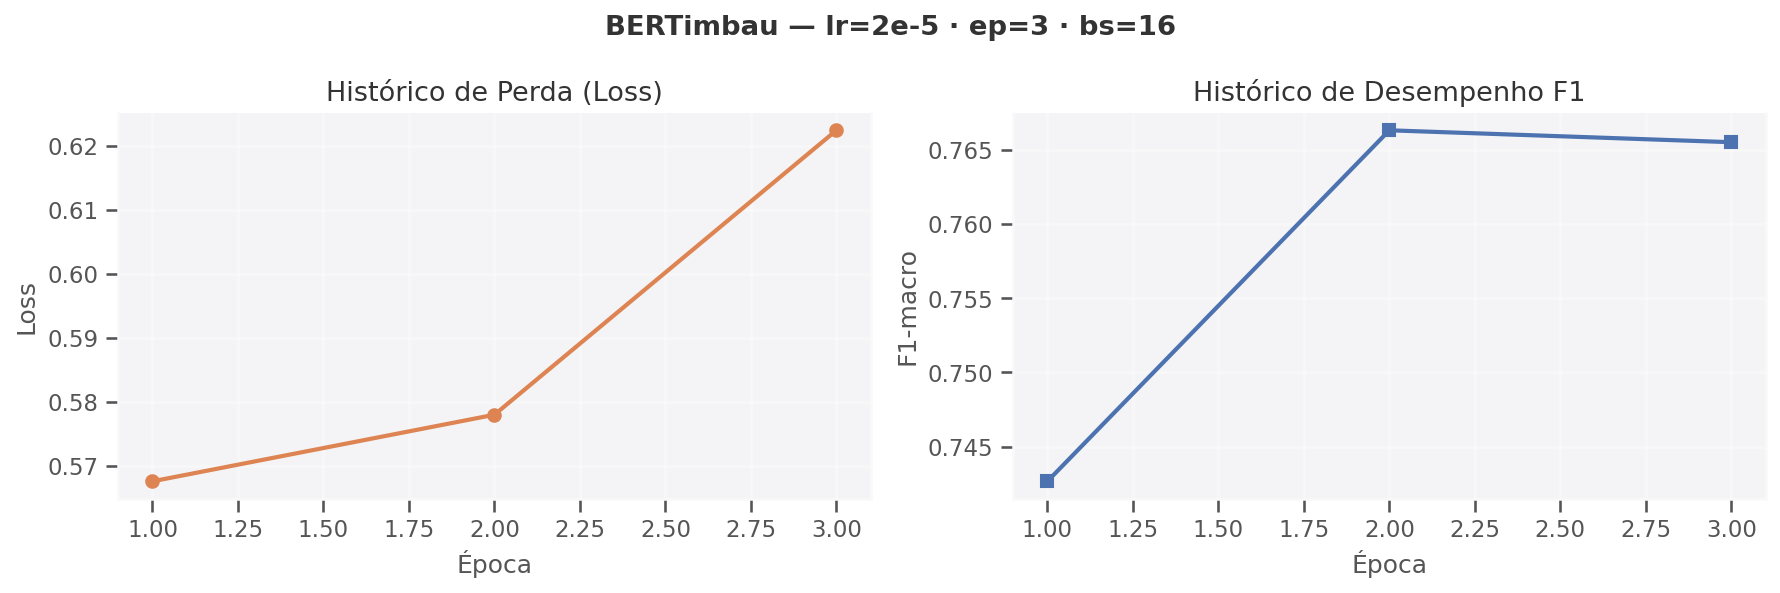

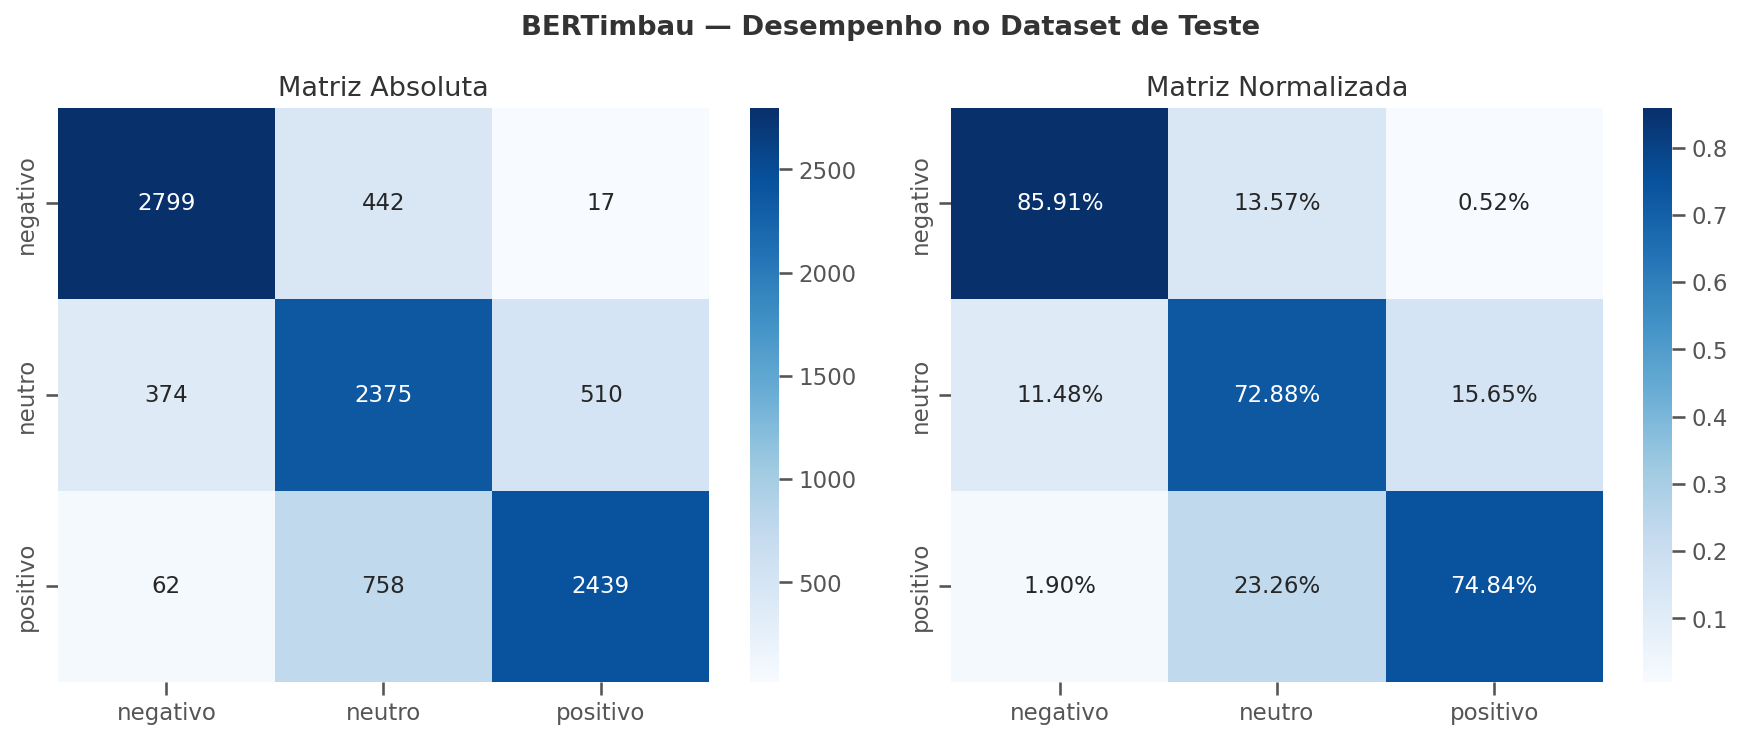

In [74]:
log_history = trainer_final.state.log_history
eval_loss   = [(l['epoch'], l['eval_loss']) for l in log_history if 'eval_loss' in l]
eval_f1     = [(l['epoch'], l['eval_f1_macro']) for l in log_history if 'eval_f1_macro' in l]

# ── Fig 1: Curva de Aprendizado ──
if eval_loss:
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
    epochs_eval = [e for e, _ in eval_loss]
    losses_eval = [l for _, l in eval_loss]
    axes1[0].plot(epochs_eval, losses_eval, marker='o', color='#dd8452', linewidth=2, label='Validação')
    axes1[0].set_xlabel('Época')
    axes1[0].set_ylabel('Loss')
    axes1[0].set_title('Histórico de Perda (Loss)')
    axes1[0].grid(True, alpha=0.3)

    if eval_f1:
        epochs_f1 = [e for e, _ in eval_f1]
        f1s       = [f for _, f in eval_f1]
        axes1[1].plot(epochs_f1, f1s, marker='s', color='#4c72b0', linewidth=2, label='F1-macro (val)')
        axes1[1].set_xlabel('Época')
        axes1[1].set_ylabel('F1-macro')
        axes1[1].set_title('Histórico de Desempenho F1')
        axes1[1].grid(True, alpha=0.3)

    plt.suptitle(f'BERTimbau — {melhor["config"]}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('figuras/fig_bert_learning_curves.png', dpi=150)
    plt.show()

# ── Fig 2: Matriz de Confusão do Teste ──
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test_raw, y_pred_labels_best, labels=CLASSES)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes3[0])
axes3[0].set_title('Matriz Absoluta')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes3[1])
axes3[1].set_title('Matriz Normalizada')
plt.suptitle('BERTimbau — Desempenho no Dataset de Teste', fontweight='bold')
plt.tight_layout()
plt.savefig('figuras/fig_bert_cm.png', dpi=150)
plt.show()

In [75]:
erros_df = pd.DataFrame({'texto': X_test_raw, 'real': y_test_raw, 'predito': y_pred_labels_best})
erros_df['correto'] = erros_df['real'] == erros_df['predito']

print("\n--- Taxa de Erro Identificada por Classe ---")
for c in CLASSES:
    sub = erros_df[erros_df['real'] == c]
    taxa = 1 - sub['correto'].mean()
    print(f"  {c:<12}: {taxa:.2%} de erro de mapeamento")

# Geração da Tabela em molde de publicação de artigos da IEEE
tabela_ieee = pd.DataFrame([{
    'Modelo'        : 'BERTimbau (fine-tuned)', 'Configuração'  : melhor['config'],
    'Acurácia'      : f"{acc_test:.4f}", 'F1-macro'      : f"{f1_test:.4f}",
    'Precision'     : f"{prec_test:.4f}", 'Recall'        : f"{rec_test:.4f}",
    'F1 (neg)'      : f"{f1_per_test[0]:.4f}", 'F1 (neu)'      : f"{f1_per_test[1]:.4f}",
    'F1 (pos)'      : f"{f1_per_test[2]:.4f}", 'Tempo treino'  : f"{t_treino_final:.0f}s",
    'Tempo inf.'    : f"{t_inf_final:.2f}ms",
    f'F1 {N_SEEDS_BERT}-seeds μ': f"{f1_arr.mean():.4f}", f'F1 {N_SEEDS_BERT}-seeds σ': f"{f1_arr.std():.4f}",
}])

tabela_ieee.to_csv('resultados/tabela_ieee_bert.csv', index=False)
erros_df.to_csv('resultados/predicoes_bert.csv', index=False)

trainer_final.save_model('resultados/best_bertimbau_model')
tokenizer.save_pretrained('resultados/best_bertimbau_model')


--- Taxa de Erro Identificada por Classe ---
  negativo    : 14.09% de erro de mapeamento
  neutro      : 27.12% de erro de mapeamento
  positivo    : 25.16% de erro de mapeamento


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('resultados/best_bertimbau_model/tokenizer_config.json',
 'resultados/best_bertimbau_model/tokenizer.json')

#7- Comparação Final

In [122]:
CLASSES = ['negativo', 'neutro', 'positivo']
MODELOS = ['TF-IDF + SVM', 'LSTM', 'BERTimbau']
CORES   = {'TF-IDF + SVM': '#4c72b0', 'LSTM': '#dd8452', 'BERTimbau': '#55a868'}

os.makedirs('figuras', exist_ok=True)

tab_svm  = pd.read_csv('resultados/tabela_ieee_svm.csv')
tab_lstm = pd.read_csv('resultados/tabela_ieee_lstm.csv')
tab_bert = pd.read_csv('resultados/tabela_ieee_bert.csv')

seeds_svm  = pd.read_csv('resultados/resultados_svm_30seeds.csv')
seeds_lstm = pd.read_csv('resultados/resultados_lstm_30seeds.csv')
seeds_bert = pd.read_csv('resultados/resultados_bert_seeds.csv')

print("Carregado: tabelas IEEE e resultados de sementes dos 3 modelos")

# --- Função auxiliar para limpar "12.3s" -> 12.3 ---
def extrai_float(serie_str):
    return float(str(serie_str).replace('s', '').replace('ms', '')
                 .split('±')[0].strip())

# --- Monta a TABLE I (a tabela principal do relatório) ---
comparativo = pd.DataFrame({
    'Modelo'      : MODELOS,
    'Acurácia'    : [tab_svm['Acurácia'][0], tab_lstm['Acurácia'][0], tab_bert['Acurácia'][0]],
    'F1-macro'    : [tab_svm['F1-macro'][0], tab_lstm['F1-macro'][0], tab_bert['F1-macro'][0]],
    'Precision'   : [tab_svm['Precision'][0], tab_lstm['Precision'][0], tab_bert['Precision'][0]],
    'Recall'      : [tab_svm['Recall'][0], tab_lstm['Recall'][0], tab_bert['Recall'][0]],
    'F1 (neg)'    : [tab_svm['F1 (neg)'][0], tab_lstm['F1 (neg)'][0], tab_bert['F1 (neg)'][0]],
    'F1 (neu)'    : [tab_svm['F1 (neu)'][0], tab_lstm['F1 (neu)'][0], tab_bert['F1 (neu)'][0]],
    'F1 (pos)'    : [tab_svm['F1 (pos)'][0], tab_lstm['F1 (pos)'][0], tab_bert['F1 (pos)'][0]],
    'Tempo treino': [tab_svm['Tempo treino'][0], tab_lstm['Tempo treino'][0], tab_bert['Tempo treino'][0]],
    'Tempo inf.'  : [tab_svm['Tempo inf.'][0], tab_lstm['Tempo inf.'][0], tab_bert['Tempo inf.'][0]],
})

print("\nTABLE I — Comparação entre modelos)")
print(comparativo.to_string(index=False))

comparativo.to_csv('resultados/TABLE_I_comparativo.csv', index=False)
print("\nSalvo: resultados/TABLE_I_comparativo.csv")

latex_table = comparativo.to_latex(index=False, escape=True,
                                    caption='Comparação entre os modelos avaliados.',
                                    label='tab:comparativo')
with open('resultados/TABLE_I_comparativo.tex', 'w') as f:
    f.write(latex_table)

Carregado: tabelas IEEE e resultados de sementes dos 3 modelos

TABLE I — Comparação entre modelos)
      Modelo  Acurácia  F1-macro  Precision  Recall  F1 (neg)  F1 (neu)  F1 (pos) Tempo treino Tempo inf.
TF-IDF + SVM    0.7503    0.7479     0.7475  0.7503    0.8394    0.6400    0.7645       1.069s   157.19ms
        LSTM    0.7619    0.7618     0.7631  0.7619    0.8522    0.6672    0.7660        19.7s    820.5ms
   BERTimbau    0.7787    0.7803     0.7840  0.7788    0.8622    0.6951    0.7836         892s     1.92ms

Salvo: resultados/TABLE_I_comparativo.csv


In [125]:
MODELOS = ['TF-IDF + SVM', 'LSTM', 'BERTimbau']

seeds_svm  = pd.read_csv('resultados/resultados_svm_30seeds.csv')
seeds_lstm = pd.read_csv('resultados/resultados_lstm_30seeds.csv')
seeds_bert = pd.read_csv('resultados/resultados_bert_seeds.csv')

f1_svm  = seeds_svm['f1_macro'].values
f1_lstm = seeds_lstm['f1_macro'].values
f1_bert = seeds_bert['f1_macro'].values

print(f"Amostras: SVM={len(f1_svm)}, LSTM={len(f1_lstm)}, BERT={len(f1_bert)}")


def teste_hipotese(grupo_a, grupo_b, nome_a, nome_b, alpha=0.05):
    """
    Escolhe o teste certo: testa normalidade primeiro (Shapiro-Wilk),
    e usa t-test de Welch se for normal, Mann-Whitney U se não for.
    """
    print(f"--- {nome_a} vs {nome_b} ---")

    _, p_norm_a = stats.shapiro(grupo_a)
    _, p_norm_b = stats.shapiro(grupo_b)
    normal = p_norm_a > alpha and p_norm_b > alpha
    print(f"  Shapiro-Wilk: {nome_a} p={p_norm_a:.4f} | {nome_b} p={p_norm_b:.4f} "
          f"→ normal: {normal}")

    if normal:
        stat, p_val = stats.ttest_ind(grupo_a, grupo_b, equal_var=False)
        teste_usado = "Welch's t-test"
    else:
        stat, p_val = stats.mannwhitneyu(grupo_a, grupo_b, alternative='two-sided')
        teste_usado = "Mann-Whitney U"

    significativo = p_val < alpha
    diferenca = grupo_a.mean() - grupo_b.mean()

    print(f"  Teste: {teste_usado} | estatística={stat:.4f} | p-valor={p_val:.6f}")
    print(f"  Diferença média: {diferenca:+.4f} → "
          f"{'SIGNIFICATIVO' if significativo else 'NÃO significativo'} (α={alpha})\n")

    return {
        'comparacao': f'{nome_a} vs {nome_b}', 'teste': teste_usado,
        'estatistica': round(stat, 4), 'p_valor': round(p_val, 6),
        'diferenca': round(diferenca, 4), 'significativo': significativo,
    }


# --- Roda as 3 comparações par a par ---
resultados_testes = [
    teste_hipotese(f1_svm, f1_lstm, 'TF-IDF+SVM', 'LSTM'),
    teste_hipotese(f1_lstm, f1_bert, 'LSTM', 'BERTimbau'),
    teste_hipotese(f1_svm, f1_bert, 'TF-IDF+SVM', 'BERTimbau'),
]

df_testes = pd.DataFrame(resultados_testes)
df_testes.to_csv('resultados/testes_hipotese.csv', index=False)
print(df_testes.to_string(index=False))

stats_desc = pd.DataFrame({
    'Modelo'   : MODELOS,
    'N (seeds)': [len(f1_svm), len(f1_lstm), len(f1_bert)],
    'Média'    : [f1_svm.mean(), f1_lstm.mean(), f1_bert.mean()],
    'Mediana'  : [np.median(f1_svm), np.median(f1_lstm), np.median(f1_bert)],
    'Desvio'   : [f1_svm.std(), f1_lstm.std(), f1_bert.std()],
    'Mínimo'   : [f1_svm.min(), f1_lstm.min(), f1_bert.min()],
    'Máximo'   : [f1_svm.max(), f1_lstm.max(), f1_bert.max()],
}).round(4)

print("\n" + stats_desc.to_string(index=False))
stats_desc.to_csv('resultados/estatisticas_descritivas.csv', index=False)

Amostras: SVM=30, LSTM=30, BERT=5
--- TF-IDF+SVM vs LSTM ---
  Shapiro-Wilk: TF-IDF+SVM p=0.8632 | LSTM p=0.0330 → normal: False
  Teste: Mann-Whitney U | estatística=23.0000 | p-valor=0.000000
  Diferença média: -0.0110 → SIGNIFICATIVO (α=0.05)

--- LSTM vs BERTimbau ---
  Shapiro-Wilk: LSTM p=0.0330 | BERTimbau p=0.6645 → normal: False
  Teste: Mann-Whitney U | estatística=119.0000 | p-valor=0.037415
  Diferença média: +0.0111 → SIGNIFICATIVO (α=0.05)

--- TF-IDF+SVM vs BERTimbau ---
  Shapiro-Wilk: TF-IDF+SVM p=0.8632 | BERTimbau p=0.6645 → normal: True
  Teste: Welch's t-test | estatística=0.0083 | p-valor=0.993783
  Diferença média: +0.0001 → NÃO significativo (α=0.05)

Salvo: resultados/testes_hipotese.csv
             comparacao          teste  estatistica  p_valor  diferenca  significativo
     TF-IDF+SVM vs LSTM Mann-Whitney U      23.0000 0.000000    -0.0110           True
      LSTM vs BERTimbau Mann-Whitney U     119.0000 0.037415     0.0111           True
TF-IDF+SVM vs BER

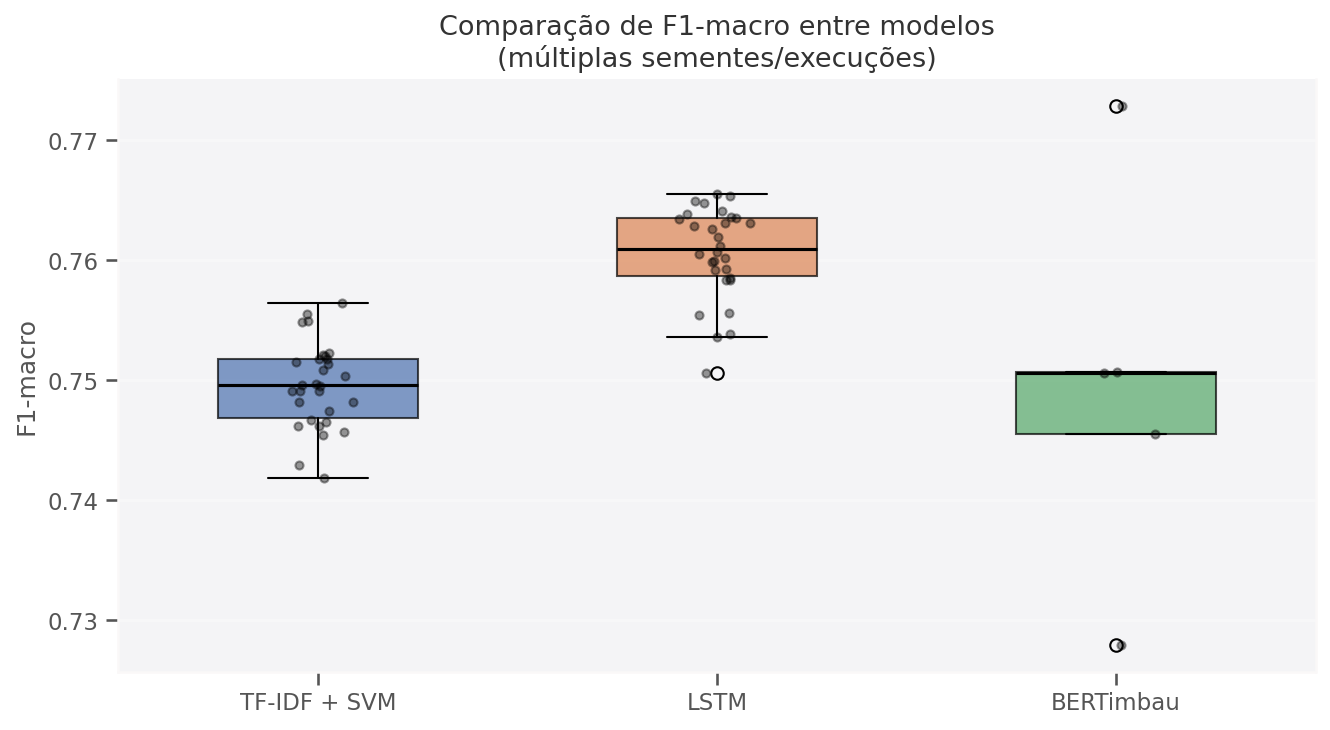

Salvo: figuras/fig_comparacao_boxplot.png


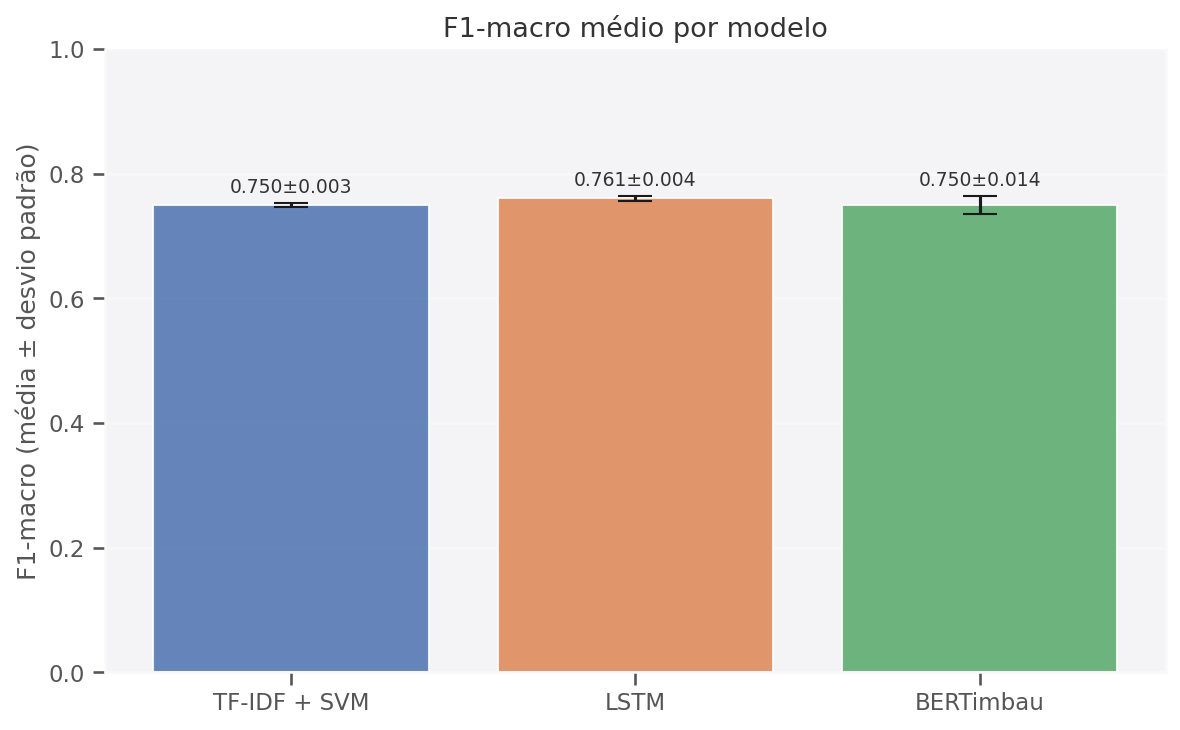

Salvo: figuras/fig_comparacao_barras.png


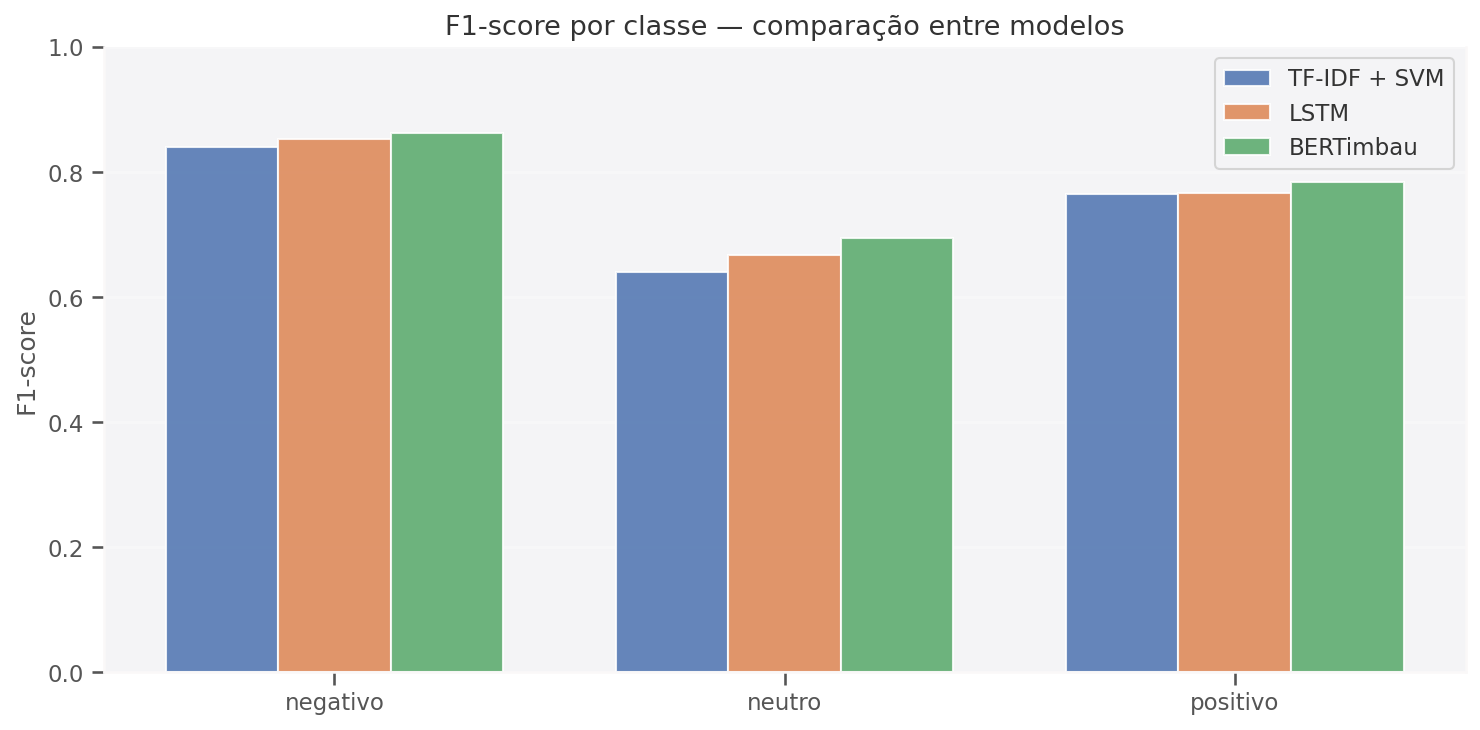

Salvo: figuras/fig_comparacao_f1_classe.png


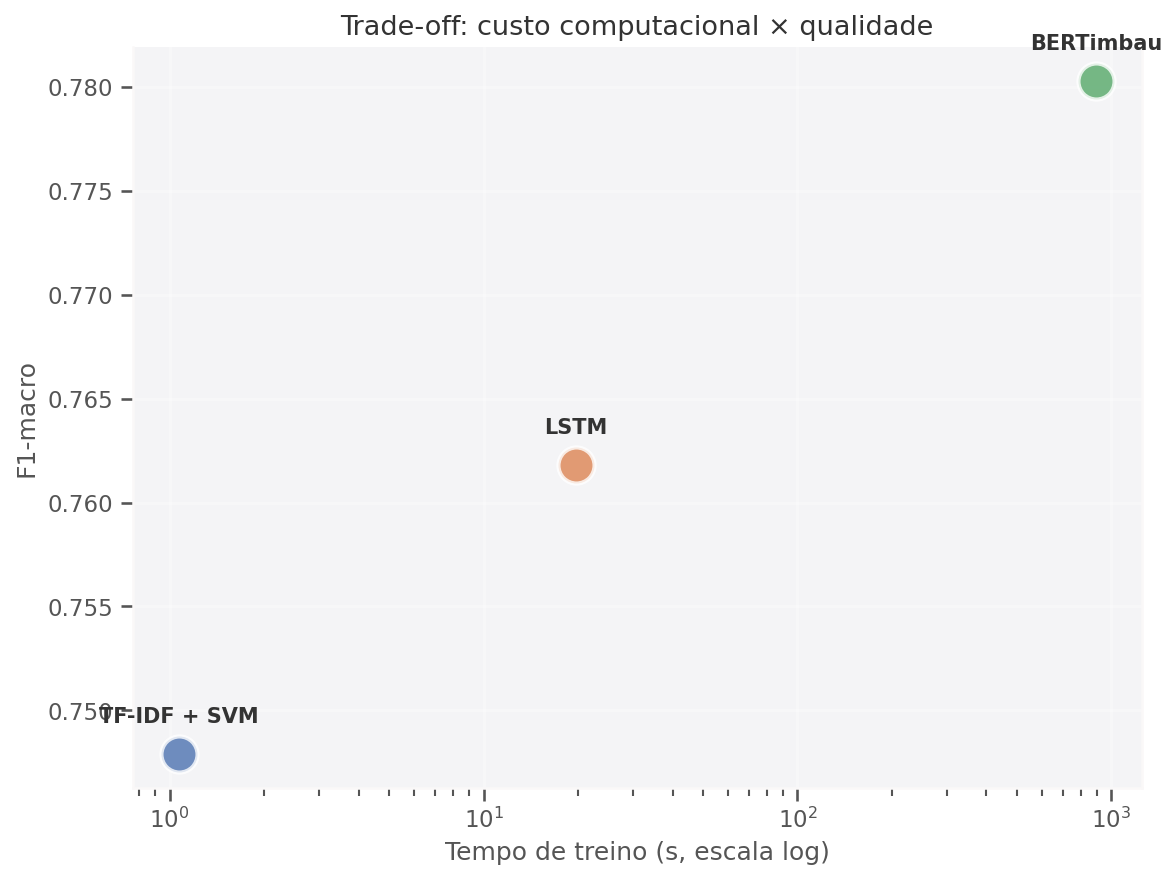

In [126]:
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13})

CLASSES = ['negativo', 'neutro', 'positivo']
MODELOS = ['TF-IDF + SVM', 'LSTM', 'BERTimbau']
CORES   = {'TF-IDF + SVM': '#4c72b0', 'LSTM': '#dd8452', 'BERTimbau': '#55a868'}

tab_svm  = pd.read_csv('resultados/tabela_ieee_svm.csv')
tab_lstm = pd.read_csv('resultados/tabela_ieee_lstm.csv')
tab_bert = pd.read_csv('resultados/tabela_ieee_bert.csv')

seeds_svm  = pd.read_csv('resultados/resultados_svm_30seeds.csv')
seeds_lstm = pd.read_csv('resultados/resultados_lstm_30seeds.csv')
seeds_bert = pd.read_csv('resultados/resultados_bert_seeds.csv')

f1_svm  = seeds_svm['f1_macro'].values
f1_lstm = seeds_lstm['f1_macro'].values
f1_bert = seeds_bert['f1_macro'].values

def extrai_float(serie_str):
    return float(str(serie_str).replace('s', '').replace('ms', '')
                 .split('±')[0].strip())

# ─────────────────────────────────────────────
# Fig 1 — Boxplot de F1-macro (a figura mais importante)
# ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(9, 5))
data_box = [f1_svm, f1_lstm, f1_bert]
bp = ax1.boxplot(data_box, labels=MODELOS, patch_artist=True,
                  medianprops=dict(color='black', linewidth=1.5), widths=0.5)
for patch, modelo in zip(bp['boxes'], MODELOS):
    patch.set_facecolor(CORES[modelo])
    patch.set_alpha(0.7)

for i, dados in enumerate(data_box, start=1):
    x_jitter = np.random.normal(i, 0.04, size=len(dados))
    ax1.scatter(x_jitter, dados, color='black', alpha=0.4, s=15, zorder=3)

ax1.set_ylabel('F1-macro')
ax1.set_title('Comparação de F1-macro entre modelos\n(múltiplas sementes/execuções)')
ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/fig_comparacao_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: figuras/fig_comparacao_boxplot.png")

# ─────────────────────────────────────────────
# Fig 2 — Barras com média ± desvio padrão
# ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
medias  = [f1_svm.mean(), f1_lstm.mean(), f1_bert.mean()]
desvios = [f1_svm.std(),  f1_lstm.std(),  f1_bert.std()]
bars = ax2.bar(MODELOS, medias, yerr=desvios, capsize=8,
               color=[CORES[m] for m in MODELOS], alpha=0.85,
               error_kw={'linewidth': 1.5})
ax2.set_ylabel('F1-macro (média ± desvio padrão)')
ax2.set_title('F1-macro médio por modelo')
ax2.set_ylim(0, 1)
for bar, val, std in zip(bars, medias, desvios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
             f'{val:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/fig_comparacao_barras.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: figuras/fig_comparacao_barras.png")

# ─────────────────────────────────────────────
# Fig 3 — F1 por classe (neg / neu / pos) entre os 3 modelos
# ─────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 5))
x, width = np.arange(len(CLASSES)), 0.25

f1_por_classe = {
    'TF-IDF + SVM': [float(tab_svm['F1 (neg)'][0]), float(tab_svm['F1 (neu)'][0]), float(tab_svm['F1 (pos)'][0])],
    'LSTM'        : [float(tab_lstm['F1 (neg)'][0]), float(tab_lstm['F1 (neu)'][0]), float(tab_lstm['F1 (pos)'][0])],
    'BERTimbau'   : [float(tab_bert['F1 (neg)'][0]), float(tab_bert['F1 (neu)'][0]), float(tab_bert['F1 (pos)'][0])],
}
for i, modelo in enumerate(MODELOS):
    ax3.bar(x + i*width, f1_por_classe[modelo], width,
            label=modelo, color=CORES[modelo], alpha=0.85)

ax3.set_xticks(x + width)
ax3.set_xticklabels(CLASSES)
ax3.set_ylabel('F1-score')
ax3.set_title('F1-score por classe — comparação entre modelos')
ax3.legend()
ax3.set_ylim(0, 1)
ax3.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/fig_comparacao_f1_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: figuras/fig_comparacao_f1_classe.png")

# ─────────────────────────────────────────────
# Fig 4 — Trade-off tempo × F1 (figura mais "decisória")
# ─────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(8, 6))
tempos = [extrai_float(tab_svm['Tempo treino'][0]),
          extrai_float(tab_lstm['Tempo treino'][0]),
          extrai_float(tab_bert['Tempo treino'][0])]
f1s    = [float(tab_svm['F1-macro'][0]), float(tab_lstm['F1-macro'][0]), float(tab_bert['F1-macro'][0])]

for modelo, t, f1 in zip(MODELOS, tempos, f1s):
    ax4.scatter(t, f1, s=300, color=CORES[modelo], alpha=0.8,
                edgecolors='white', linewidth=2, label=modelo, zorder=3)
    ax4.annotate(modelo, (t, f1), textcoords="offset points",
                 xytext=(0, 15), ha='center', fontsize=10, fontweight='bold')

ax4.set_xscale('log')
ax4.set_xlabel('Tempo de treino (s, escala log)')
ax4.set_ylabel('F1-macro')
ax4.set_title('Trade-off: custo computacional × qualidade')
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/fig_comparacao_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [128]:
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13})

CLASSES = ['negativo', 'neutro', 'positivo']
MODELOS = ['TF-IDF + SVM', 'LSTM', 'BERTimbau']
CORES   = {'TF-IDF + SVM': '#4c72b0', 'LSTM': '#dd8452', 'BERTimbau': '#55a868'}

comparativo = pd.read_csv('resultados/TABLE_I_comparativo.csv')

def extrai_float(serie_str):
    return float(str(serie_str).replace('s', '').replace('ms', '')
                 .split('±')[0].strip())

# ─────────────────────────────────────────────
# Parte A — taxa de erro por classe e por modelo
# ─────────────────────────────────────────────
try:
    pred_svm  = pd.read_csv('resultados/predicoes_svm.csv')
    pred_lstm = pd.read_csv('resultados/predicoes_lstm.csv')
    pred_bert = pd.read_csv('resultados/predicoes_bert.csv')

    erro_comparativo = []
    for nome, df_pred, col_real, col_pred in [
        ('TF-IDF + SVM', pred_svm,  'sentimento', 'predito'),
        ('LSTM',         pred_lstm, 'sentimento', 'predito'),
        ('BERTimbau',    pred_bert, 'real',        'predito'),
    ]:
        for c in CLASSES:
            sub = df_pred[df_pred[col_real] == c]
            if len(sub) > 0:
                taxa_erro = 1 - (sub[col_real] == sub[col_pred]).mean()
                erro_comparativo.append({
                    'modelo': nome, 'classe': c,
                    'taxa_erro': round(taxa_erro, 4), 'n': len(sub)
                })

    df_erro_comp = pd.DataFrame(erro_comparativo)
    print(df_erro_comp.to_string(index=False))
    df_erro_comp.to_csv('resultados/erro_comparativo.csv', index=False)
    print("\nSalvo: resultados/erro_comparativo.csv")

    fig8, ax8 = plt.subplots(figsize=(9, 5))
    pivot_erro = df_erro_comp.pivot(index='classe', columns='modelo', values='taxa_erro')
    pivot_erro = pivot_erro[MODELOS]
    pivot_erro.plot(kind='bar', ax=ax8, color=[CORES[m] for m in MODELOS], alpha=0.85)
    ax8.set_ylabel('Taxa de erro')
    ax8.set_title('Taxa de erro por classe e por modelo')
    ax8.set_xlabel('')
    ax8.tick_params(axis='x', rotation=0)
    ax8.legend(title='Modelo')
    ax8.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('figuras/fig_comparacao_erro_classe.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Salvo: figuras/fig_comparacao_erro_classe.png")

except FileNotFoundError as e:
    print(f"Arquivo de predições não encontrado, pulando análise de erros: {e}")

# ─────────────────────────────────────────────
# Parte B — ranking e recomendação final
# ─────────────────────────────────────────────
ranking = comparativo.copy()
ranking['F1-macro_num'] = ranking['F1-macro'].astype(float)
ranking = ranking.sort_values('F1-macro_num', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1

print("\nRanking por F1-macro:")
for i, row in ranking.iterrows():
    print(f"  {i}º lugar: {row['Modelo']:<15} F1-macro = {row['F1-macro']}")

melhor_modelo = ranking.iloc[0]['Modelo']
melhor_tempo  = ranking.loc[ranking['Tempo treino'].apply(extrai_float).idxmin(), 'Modelo']

print(f"\n  → Melhor desempenho (F1-macro): {melhor_modelo}")
print(f"  → Mais rápido para treinar     : {melhor_tempo}")
print(f"\n  Recomendação de uso:")
print(f"  - Prioridade QUALIDADE máxima  → {melhor_modelo}")
print(f"  - Prioridade VELOCIDADE/CUSTO  → {melhor_tempo}")
print(f"  - Veja o trade-off completo em fig_comparacao_tradeoff.png")

Arquivo de predições não encontrado, pulando análise de erros: [Errno 2] No such file or directory: 'resultados/predicoes_svm.csv'

Ranking por F1-macro:
  1º lugar: BERTimbau       F1-macro = 0.7803
  2º lugar: LSTM            F1-macro = 0.7618
  3º lugar: TF-IDF + SVM    F1-macro = 0.7479

  → Melhor desempenho (F1-macro): BERTimbau
  → Mais rápido para treinar     : TF-IDF + SVM

  Recomendação de uso:
  - Prioridade QUALIDADE máxima  → BERTimbau
  - Prioridade VELOCIDADE/CUSTO  → TF-IDF + SVM
  - Veja o trade-off completo em fig_comparacao_tradeoff.png
